# PROJET SESSION NORMALE DEEP LEARNING ANN
## Prédiction des cours de l'action Salesforce (CRM)
### Modèles: GRU et Neural Prophet | Framework: PyTorch

---

**Action:** Salesforce (CRM)  
**Modèles:** GRU (Gated Recurrent Unit), Neural Prophet  
**Framework:** PyTorch  
**Dataset:** Données historiques 2004-2026

---

## PARTIE 1: IMPORTATION DES BIBLIOTHÈQUES

In [2]:
# Bibliothèques de base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Scikit-learn pour preprocessing et métriques
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Neural Prophet
from neuralprophet import NeuralProphet

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

# Seed pour reproductibilité
np.random.seed(42)
torch.manual_seed(42)

# Vérifier si CUDA est disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("=" * 70)
print("CONFIGURATION DU SYSTÈME")
print("=" * 70)
print(f"Device utilisé: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("=" * 70)

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


CONFIGURATION DU SYSTÈME
Device utilisé: cuda
PyTorch version: 2.5.1+cu121
NumPy version: 1.26.4
Pandas version: 2.3.3


## PARTIE 2: CHARGEMENT ET EXPLORATION DES DONNÉES

In [3]:
# Chargement des données
df = pd.read_csv('salesforce_data.csv')

# Conversion de la colonne Date
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df['Date'] = df['Date'].dt.tz_localize(None)

# Trier par date
df = df.sort_values('Date').reset_index(drop=True)

print("=" * 70)
print("DONNÉES CHARGÉES - SALESFORCE (CRM)")
print("=" * 70)
print(f"Shape des données: {df.shape}")
print(f"Période: {df['Date'].min()} à {df['Date'].max()}")
print(f"Nombre de jours: {len(df)}")
print(f"\nColonnes disponibles: {list(df.columns)}")
print("=" * 70)

DONNÉES CHARGÉES - SALESFORCE (CRM)
Shape des données: (5447, 8)
Période: 2004-06-23 04:00:00 à 2026-02-13 05:00:00
Nombre de jours: 5447

Colonnes disponibles: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock Splits']


In [4]:
# Aperçu des premières lignes
print("Premières lignes du dataset:")
df.head(10)

Premières lignes du dataset:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2004-06-23 04:00:00,3.704984,4.273081,3.643234,4.248382,43574400,0.0,0.0
1,2004-06-24 04:00:00,4.334830,4.369410,4.075482,4.139701,8887200,0.0,0.0
2,2004-06-25 04:00:00,4.077952,4.137232,3.900113,3.902583,6710000,0.0,0.0
3,2004-06-28 04:00:00,3.951982,4.003852,3.813663,3.951982,2270800,0.0,0.0
4,2004-06-29 04:00:00,3.951983,4.124882,3.909993,4.050782,2112000,0.0,0.0
5,2004-06-30 04:00:00,4.050782,4.184162,3.959393,3.969272,2087600,0.0,0.0
6,2004-07-01 04:00:00,3.971742,4.001382,3.927282,3.959393,1754800,0.0,0.0
7,2004-07-02 04:00:00,3.976682,4.194041,3.964332,4.194041,993200,0.0,0.0
8,2004-07-06 04:00:00,4.181691,4.198981,4.070542,4.198981,1216800,0.0,0.0
9,2004-07-07 04:00:00,4.174281,4.174281,3.964332,4.028552,1787600,0.0,0.0


In [5]:
# Dernières lignes
print("Dernières lignes du dataset:")
df.tail(10)

Dernières lignes du dataset:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
5437,2026-02-02 05:00:00,214.350006,216.889999,209.800003,210.809998,7950900,0.0,0.0
5438,2026-02-03 05:00:00,205.000000,205.559998,193.110001,196.380005,20194200,0.0,0.0
5439,2026-02-04 05:00:00,193.309998,200.669998,187.279999,199.440002,23010000,0.0,0.0
5440,2026-02-05 05:00:00,193.990005,199.559998,188.789993,189.970001,21956300,0.0,0.0
5441,2026-02-06 05:00:00,191.630005,194.600006,187.119995,191.350006,13652600,0.0,0.0
5442,2026-02-09 05:00:00,189.300003,195.199997,185.729996,194.029999,12112000,0.0,0.0
5443,2026-02-10 05:00:00,191.899994,199.100006,190.750000,193.449997,13393000,0.0,0.0
5444,2026-02-11 05:00:00,193.149994,193.669998,181.809998,185.000000,16350200,0.0,0.0
5445,2026-02-12 05:00:00,185.960007,188.320007,180.240005,185.429993,16849100,0.0,0.0
5446,2026-02-13 05:00:00,186.440002,193.449997,184.300003,189.720001,14795084,0.0,0.0


In [6]:
# Informations sur le dataset
print("Informations sur le dataset:")
df.info()

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5447 entries, 0 to 5446
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          5447 non-null   datetime64[ns]
 1   Open          5447 non-null   float64       
 2   High          5447 non-null   float64       
 3   Low           5447 non-null   float64       
 4   Close         5447 non-null   float64       
 5   Volume        5447 non-null   int64         
 6   Dividends     5447 non-null   float64       
 7   Stock Splits  5447 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(1)
memory usage: 340.6 KB


In [7]:
# Statistiques descriptives
print("Statistiques descriptives:")
df.describe()

Statistiques descriptives:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,5447,5447.000000,5447.000000,5447.000000,5447.000000,5.447000e+03,5447.000000,5447.000000
mean,2015-04-16 21:13:52.751973632,99.513598,100.761412,98.192815,99.509887,6.959768e+06,0.000599,0.000734
min,2004-06-23 04:00:00,2.371190,2.432939,2.222990,2.368719,4.636000e+05,0.000000,0.000000
25%,2009-11-16 17:00:00,16.730472,17.039219,16.427899,16.783573,4.080650e+06,0.000000,0.000000
50%,2015-04-17 04:00:00,65.790624,66.748984,65.089139,66.047508,5.657200e+06,0.000000,0.000000
75%,2020-09-12 16:00:00,163.320633,165.978309,161.527418,164.002342,8.233300e+06,0.000000,0.000000
max,2026-02-13 05:00:00,364.015522,366.188840,358.339101,365.067444,8.733240e+07,0.416000,4.000000
std,NaN,92.544435,93.611287,91.363930,92.489366,5.153962e+06,0.015629,0.054198


In [8]:
# Vérifier les valeurs manquantes
print("=" * 70)
print("VÉRIFICATION DES VALEURS MANQUANTES")
print("=" * 70)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Colonne': missing.index,
    'Valeurs manquantes': missing.values,
    'Pourcentage (%)': missing_pct.values
})
print(missing_df)
print("=" * 70)

VÉRIFICATION DES VALEURS MANQUANTES
        Colonne  Valeurs manquantes  Pourcentage (%)
0          Date                   0              0.0
1          Open                   0              0.0
2          High                   0              0.0
3           Low                   0              0.0
4         Close                   0              0.0
5        Volume                   0              0.0
6     Dividends                   0              0.0
7  Stock Splits                   0              0.0


## PARTIE 3: ANALYSE EXPLORATOIRE DES DONNÉES (EDA)

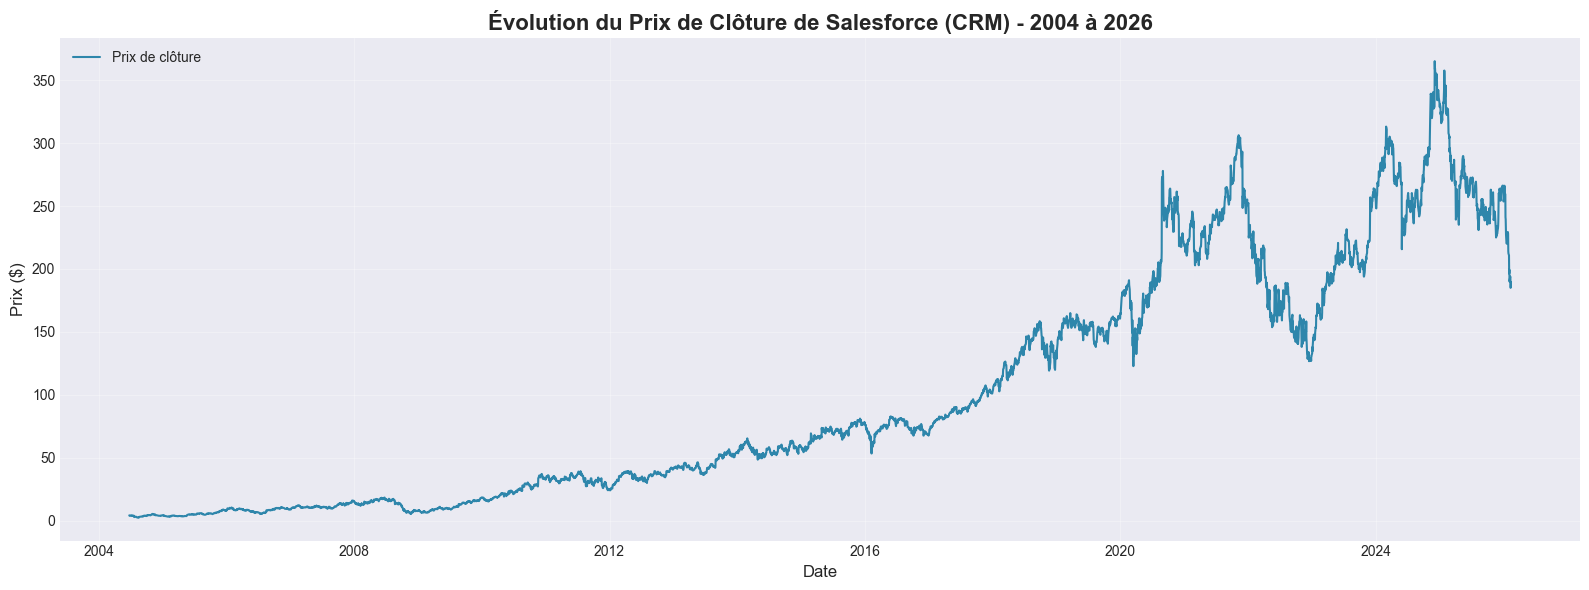

Prix minimum: $2.37
Prix maximum: $365.07
Prix moyen: $99.51
Prix actuel: $189.72
Rendement total: 4365.70%


In [9]:
# Graphique 1: Évolution du prix de clôture
plt.figure(figsize=(16, 6))
plt.plot(df['Date'], df['Close'], linewidth=1.5, color='#2E86AB', label='Prix de clôture')
plt.title('Évolution du Prix de Clôture de Salesforce (CRM) - 2004 à 2026', 
          fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Prix ($)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Informations clés
print(f"Prix minimum: ${df['Close'].min():.2f}")
print(f"Prix maximum: ${df['Close'].max():.2f}")
print(f"Prix moyen: ${df['Close'].mean():.2f}")
print(f"Prix actuel: ${df['Close'].iloc[-1]:.2f}")
print(f"Rendement total: {((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100:.2f}%")

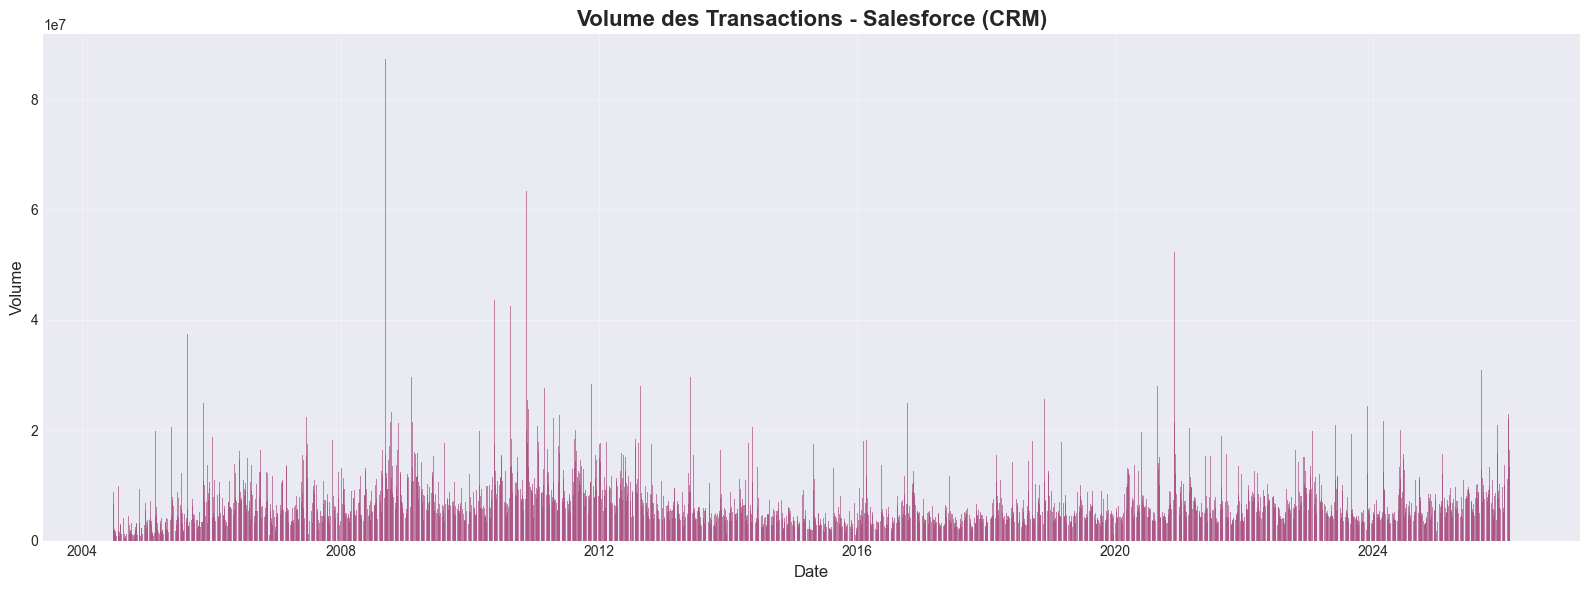

Volume moyen: 6,959,768
Volume maximum: 87,332,400


In [10]:
# Graphique 2: Volume des transactions
plt.figure(figsize=(16, 6))
plt.bar(df['Date'], df['Volume'], width=2, color='#A23B72', alpha=0.6)
plt.title('Volume des Transactions - Salesforce (CRM)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Volume', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Volume moyen: {df['Volume'].mean():,.0f}")
print(f"Volume maximum: {df['Volume'].max():,.0f}")

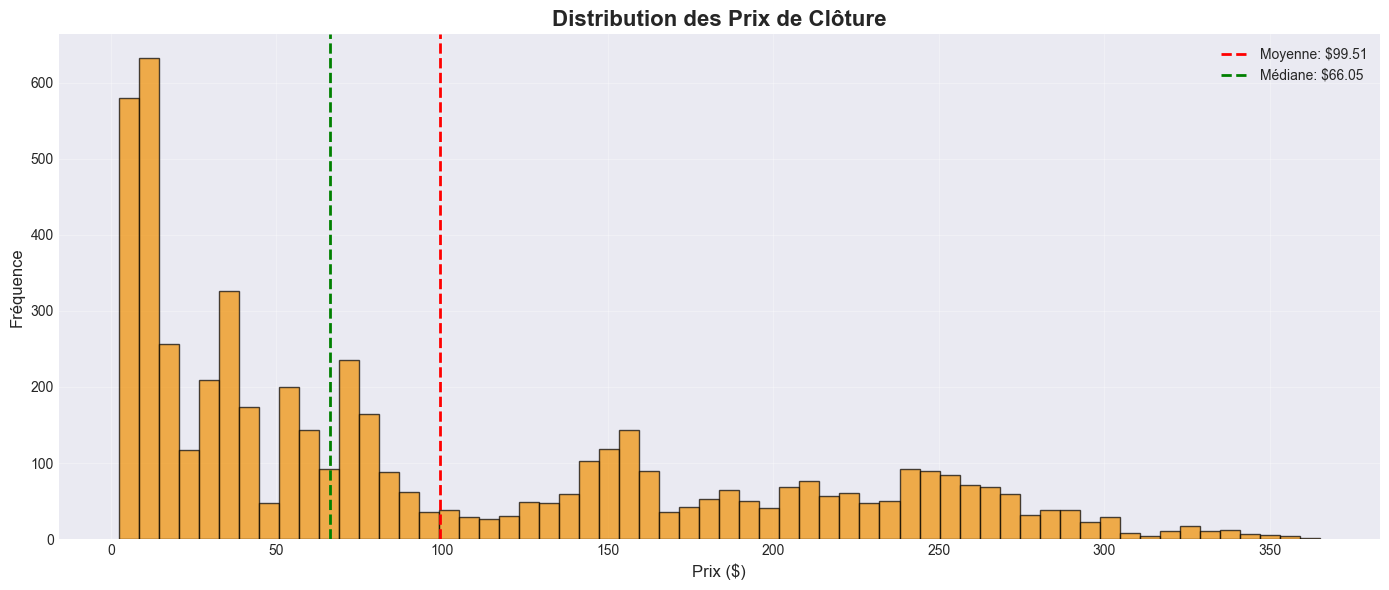

In [11]:
# Graphique 3: Distribution des prix de clôture
plt.figure(figsize=(14, 6))
plt.hist(df['Close'], bins=60, color='#F18F01', edgecolor='black', alpha=0.7)
plt.axvline(df['Close'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne: ${df['Close'].mean():.2f}")
plt.axvline(df['Close'].median(), color='green', linestyle='--', linewidth=2, label=f"Médiane: ${df['Close'].median():.2f}")
plt.title('Distribution des Prix de Clôture', fontsize=16, fontweight='bold')
plt.xlabel('Prix ($)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

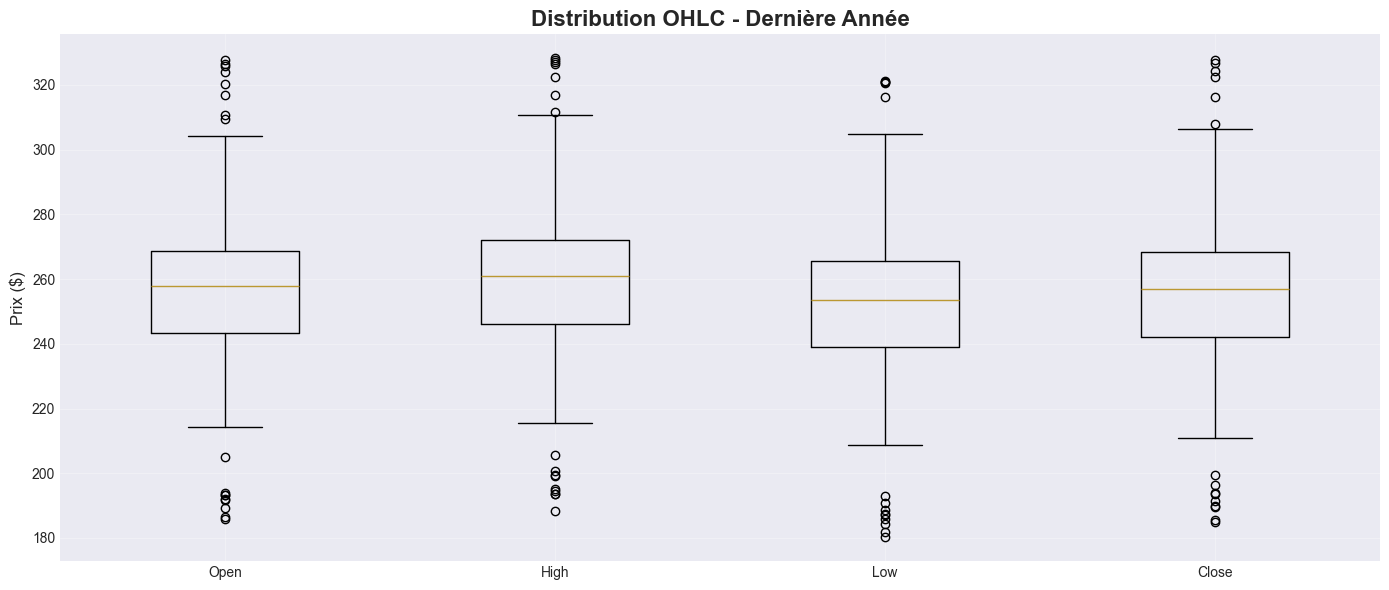

In [12]:
# Graphique 4: Analyse OHLC (dernière année)
df_recent = df.tail(252)  # Dernière année (environ 252 jours de trading)

fig, ax = plt.subplots(figsize=(14, 6))
ax.boxplot([df_recent['Open'], df_recent['High'], df_recent['Low'], df_recent['Close']], 
           labels=['Open', 'High', 'Low', 'Close'])
ax.set_title('Distribution OHLC - Dernière Année', fontsize=16, fontweight='bold')
ax.set_ylabel('Prix ($)', fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## PARTIE 4: FEATURE ENGINEERING (CRÉATION DE NOUVELLES VARIABLES)

In [13]:
print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

# 1. Rendements quotidiens (Returns)
df['Returns'] = df['Close'].pct_change()
print("✓ Returns créé")

# 2. Moyennes mobiles
df['MA7'] = df['Close'].rolling(window=7).mean()   # 1 semaine
df['MA30'] = df['Close'].rolling(window=30).mean()  # 1 mois
df['MA90'] = df['Close'].rolling(window=90).mean()  # 3 mois
print("✓ Moyennes mobiles (MA7, MA30, MA90) créées")

# 3. Volatilité (écart-type mobile sur 30 jours)
df['Volatility'] = df['Returns'].rolling(window=30).std()
print("✓ Volatilité créée")

# 4. Écart High-Low
df['HL_Spread'] = df['High'] - df['Low']
print("✓ HL_Spread créé")

# 5. Ratio Close/Open
df['CO_Ratio'] = df['Close'] / df['Open']
print("✓ CO_Ratio créé")

# 6. RSI (Relative Strength Index) - 14 jours
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df['RSI'] = calculate_rsi(df['Close'], window=14)
print("✓ RSI créé")

# 7. Tendance (lag features)
df['Close_Lag1'] = df['Close'].shift(1)  # Prix du jour précédent
df['Close_Lag7'] = df['Close'].shift(7)  # Prix d'il y a 7 jours
print("✓ Lag features créés")

print("\n" + "=" * 70)
print(f"Nouvelles features créées: {len(df.columns) - 8}")
print(f"Colonnes totales: {len(df.columns)}")
print("=" * 70)

FEATURE ENGINEERING
✓ Returns créé
✓ Moyennes mobiles (MA7, MA30, MA90) créées
✓ Volatilité créée
✓ HL_Spread créé
✓ CO_Ratio créé
✓ RSI créé
✓ Lag features créés

Nouvelles features créées: 10
Colonnes totales: 18


In [14]:
# Afficher les nouvelles colonnes
print("\nAperçu des données avec les nouvelles features:")
df.head(100).tail(10)  # Afficher après que les moyennes mobiles soient calculées


Aperçu des données avec les nouvelles features:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,MA7,MA30,MA90,Volatility,HL_Spread,CO_Ratio,RSI,Close_Lag1,Close_Lag7
90,2004-10-29 04:00:00,4.964678,5.019018,4.794249,5.019018,1799600,0.0,0.0,0.008437,4.662634,4.312601,3.708716,0.031356,0.224769,1.010945,69.597024,4.977028,4.483030
91,2004-11-01 05:00:00,5.063477,5.433976,5.038777,5.359876,3213600,0.0,0.0,0.067913,4.779076,4.359448,3.722273,0.033080,0.395198,1.058537,74.962241,5.019018,4.544780
92,2004-11-02 05:00:00,5.557476,5.557476,5.377167,5.424096,3029600,0.0,0.0,0.011982,4.939978,4.405555,3.739179,0.033015,0.180309,0.976000,75.516165,5.359876,4.297781
93,2004-11-03 05:00:00,5.485845,5.606875,5.310476,5.352466,1917600,0.0,0.0,-0.013206,5.064183,4.451661,3.754740,0.032892,0.296399,0.975687,78.048721,5.424096,4.483030
94,2004-11-04 05:00:00,5.335176,5.367285,5.063477,5.083237,1398400,0.0,0.0,-0.050300,5.139341,4.491757,3.766212,0.034223,0.303808,0.952778,67.015685,5.352466,4.557130
95,2004-11-05 05:00:00,5.144987,5.275897,5.075828,5.152398,1574800,0.0,0.0,0.013606,5.195445,4.531442,3.779358,0.034164,0.200069,1.001440,66.885670,5.083237,4.759669
96,2004-11-08 05:00:00,5.152397,5.152397,5.004198,5.038777,1014400,0.0,0.0,-0.022052,5.204267,4.571044,3.791351,0.033955,0.148199,0.977948,63.545532,5.152398,4.977028
97,2004-11-09 05:00:00,4.865879,4.952328,4.720149,4.823889,1935600,0.0,0.0,-0.042647,5.176391,4.608341,3.798349,0.034196,0.232179,0.991371,57.840894,5.038777,5.019018
98,2004-11-10 05:00:00,4.853528,4.853528,4.757199,4.823889,779200,0.0,0.0,0.000000,5.099822,4.639463,3.805293,0.033357,0.096329,0.993893,56.608169,4.823889,5.359876
99,2004-11-11 05:00:00,4.823889,4.974558,4.804129,4.944919,1007200,0.0,0.0,0.025090,5.031368,4.675607,3.815474,0.033373,0.170429,1.025090,66.293529,4.823889,5.424096


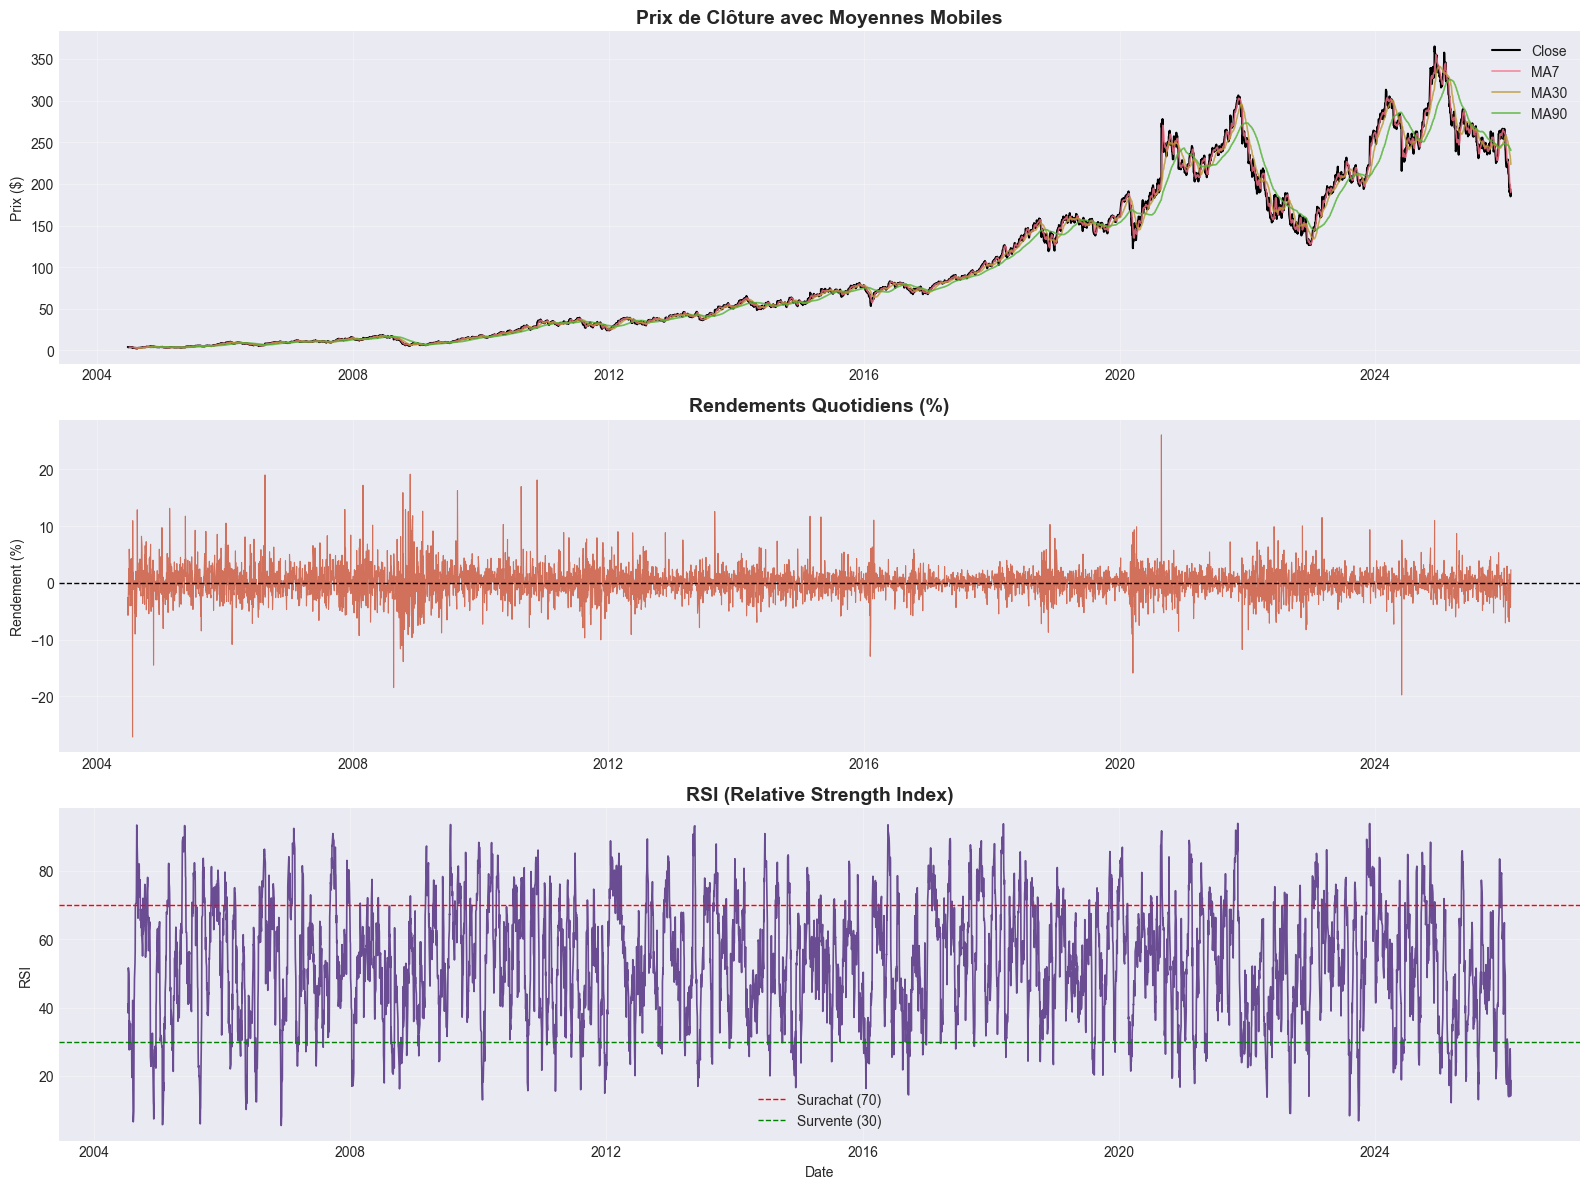

In [15]:
# Visualiser quelques features techniques
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Prix avec moyennes mobiles
axes[0].plot(df['Date'], df['Close'], label='Close', linewidth=1.5, color='black')
axes[0].plot(df['Date'], df['MA7'], label='MA7', linewidth=1.2, alpha=0.8)
axes[0].plot(df['Date'], df['MA30'], label='MA30', linewidth=1.2, alpha=0.8)
axes[0].plot(df['Date'], df['MA90'], label='MA90', linewidth=1.2, alpha=0.8)
axes[0].set_title('Prix de Clôture avec Moyennes Mobiles', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Prix ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Rendements quotidiens
axes[1].plot(df['Date'], df['Returns']*100, linewidth=0.8, color='#C73E1D', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Rendements Quotidiens (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Rendement (%)')
axes[1].grid(True, alpha=0.3)

# 3. RSI
axes[2].plot(df['Date'], df['RSI'], linewidth=1.2, color='#6A4C93')
axes[2].axhline(70, color='red', linestyle='--', linewidth=1, label='Surachat (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=1, label='Survente (30)')
axes[2].set_title('RSI (Relative Strength Index)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('RSI')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PARTIE 5: NETTOYAGE ET PRÉPARATION FINALE DES DONNÉES

In [16]:
print("=" * 70)
print("NETTOYAGE DES DONNÉES")
print("=" * 70)

# Afficher les valeurs manquantes avant nettoyage
print("\nValeurs manquantes AVANT nettoyage:")
print(df.isnull().sum())

# Sauvegarder le nombre de lignes initial
initial_rows = len(df)
print(f"\nNombre de lignes initial: {initial_rows}")

# Supprimer les lignes avec des valeurs manquantes
df_clean = df.dropna().reset_index(drop=True)

# Afficher le résultat
final_rows = len(df_clean)
removed_rows = initial_rows - final_rows

print(f"Nombre de lignes final: {final_rows}")
print(f"Lignes supprimées: {removed_rows}")

print("\nValeurs manquantes APRÈS nettoyage:")
print(df_clean.isnull().sum())

print("\n" + "=" * 70)
print("✓ Nettoyage terminé avec succès!")
print("=" * 70)

NETTOYAGE DES DONNÉES

Valeurs manquantes AVANT nettoyage:
Date             0
Open             0
High             0
Low              0
Close            0
Volume           0
Dividends        0
Stock Splits     0
Returns          1
MA7              6
MA30            29
MA90            89
Volatility      30
HL_Spread        0
CO_Ratio         0
RSI             13
Close_Lag1       1
Close_Lag7       7
dtype: int64

Nombre de lignes initial: 5447
Nombre de lignes final: 5358
Lignes supprimées: 89

Valeurs manquantes APRÈS nettoyage:
Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
Returns         0
MA7             0
MA30            0
MA90            0
Volatility      0
HL_Spread       0
CO_Ratio        0
RSI             0
Close_Lag1      0
Close_Lag7      0
dtype: int64

✓ Nettoyage terminé avec succès!


In [17]:
# Afficher les statistiques finales
print("\nStatistiques des données nettoyées:")
df_clean.describe()


Statistiques des données nettoyées:


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Returns,MA7,MA30,MA90,Volatility,HL_Spread,CO_Ratio,RSI,Close_Lag1,Close_Lag7
count,5358,5358.000000,5358.000000,5358.000000,5358.000000,5.358000e+03,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000,5358.000000
mean,2015-06-20 10:31:15.251959552,101.105371,102.372378,99.764365,101.101589,7.030335e+06,0.000609,0.000747,0.001016,100.998419,100.548512,99.188479,0.023654,2.608012,1.000850,53.268532,101.067069,100.859461
min,2004-10-28 04:00:00,3.223335,3.309785,3.201106,3.228276,5.144000e+05,0.000000,0.000000,-0.197371,3.340484,3.525580,3.692496,0.006537,0.034580,0.855798,5.519703,3.228276,3.228276
25%,2010-02-24 11:00:00,18.192704,18.450817,17.951264,18.230371,4.138600e+06,0.000000,0.000000,-0.011351,17.925768,17.247439,16.636055,0.016128,0.642198,0.989760,40.574341,18.204435,17.994485
50%,2015-06-20 16:00:00,68.344602,69.218972,67.401067,68.324829,5.712100e+06,0.000000,0.000000,0.000547,68.259203,67.987766,68.142386,0.021836,1.384433,1.000495,53.605690,68.319885,67.712276
75%,2020-10-13 22:00:00,166.521731,170.340324,164.145578,167.601112,8.299600e+06,0.000000,0.000000,0.013129,168.421142,167.977199,164.442564,0.028890,3.863066,1.011514,65.851356,167.586308,166.057365
max,2026-02-13 05:00:00,364.015522,366.188840,358.339101,365.067444,8.733240e+07,0.416000,4.000000,0.260449,355.061406,340.814946,325.136117,0.075601,28.157877,1.153691,93.834157,365.067444,365.067444
std,NaN,92.475160,93.540324,91.295451,92.419207,5.122427e+06,0.015758,0.054646,0.025686,92.367503,92.156246,91.373743,0.010242,2.896099,0.021494,17.077478,92.420643,92.429078


## PARTIE 6: PRÉPARATION DES DONNÉES POUR LES MODÈLES DE DEEP LEARNING

### 6.1 Sélection des Features

In [18]:
# Sélectionner les features pour l'entraînement
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume', 
                   'Returns', 'MA7', 'MA30', 'MA90', 
                   'Volatility', 'HL_Spread', 'CO_Ratio', 'RSI']

# Variable cible
target_column = 'Close'

print("=" * 70)
print("FEATURES SÉLECTIONNÉES POUR LES MODÈLES")
print("=" * 70)
print(f"\nNombre de features: {len(feature_columns)}")
print(f"\nFeatures:")
for i, feat in enumerate(feature_columns, 1):
    print(f"  {i}. {feat}")
print(f"\nTarget (variable à prédire): {target_column}")
print("=" * 70)

FEATURES SÉLECTIONNÉES POUR LES MODÈLES

Nombre de features: 13

Features:
  1. Open
  2. High
  3. Low
  4. Close
  5. Volume
  6. Returns
  7. MA7
  8. MA30
  9. MA90
  10. Volatility
  11. HL_Spread
  12. CO_Ratio
  13. RSI

Target (variable à prédire): Close


### 6.2 Division Train/Test

In [19]:
# Ratio de division: 80% train, 20% test
train_size = 0.8
split_index = int(len(df_clean) * train_size)

# Division temporelle (importante pour les séries temporelles!)
train_data = df_clean[:split_index].copy()
test_data = df_clean[split_index:].copy()

print("=" * 70)
print("DIVISION TRAIN/TEST")
print("=" * 70)
print(f"\nDonnées totales: {len(df_clean)} jours")
print(f"\nTrain set: {len(train_data)} jours ({len(train_data)/len(df_clean)*100:.1f}%)")
print(f"  Période: {train_data['Date'].min()} à {train_data['Date'].max()}")
print(f"\nTest set: {len(test_data)} jours ({len(test_data)/len(df_clean)*100:.1f}%)")
print(f"  Période: {test_data['Date'].min()} à {test_data['Date'].max()}")
print("=" * 70)

DIVISION TRAIN/TEST

Données totales: 5358 jours

Train set: 4286 jours (80.0%)
  Période: 2004-10-28 04:00:00 à 2021-11-04 04:00:00

Test set: 1072 jours (20.0%)
  Période: 2021-11-05 04:00:00 à 2026-02-13 05:00:00


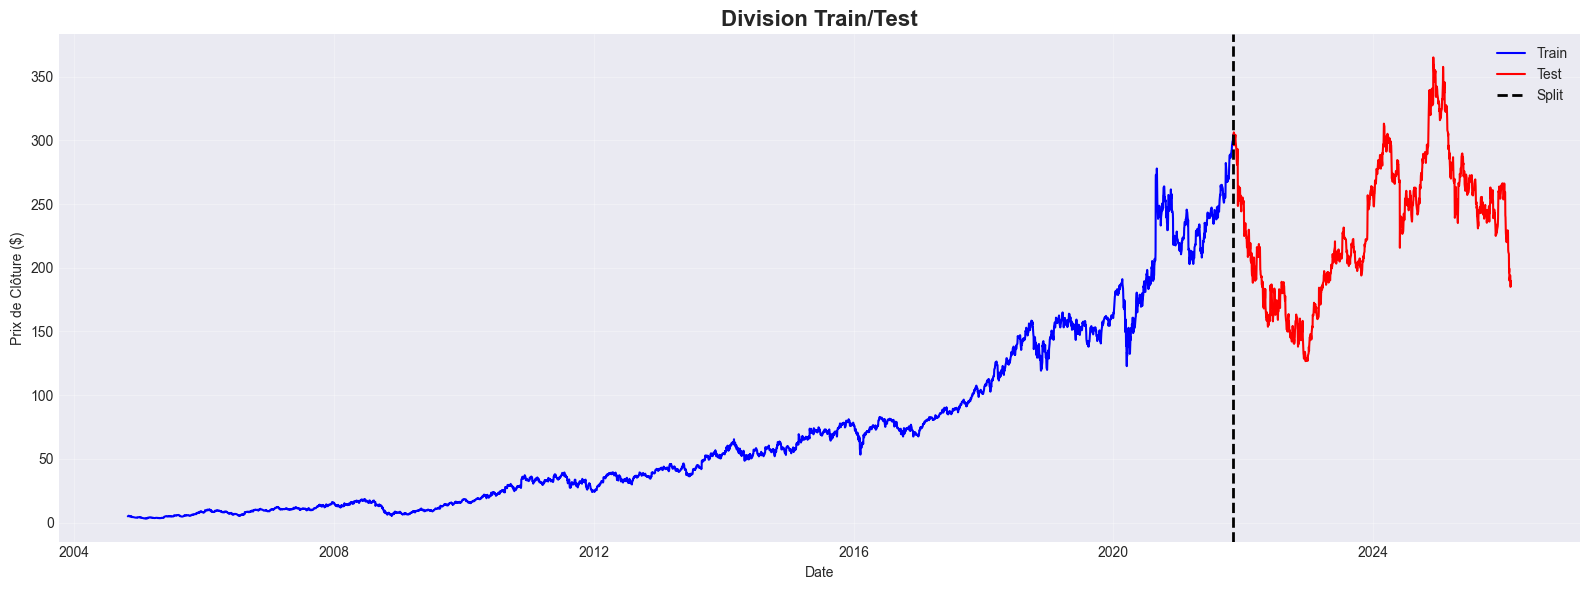

In [20]:
# Visualiser la division
plt.figure(figsize=(16, 6))
plt.plot(train_data['Date'], train_data['Close'], label='Train', linewidth=1.5, color='blue')
plt.plot(test_data['Date'], test_data['Close'], label='Test', linewidth=1.5, color='red')
plt.axvline(train_data['Date'].iloc[-1], color='black', linestyle='--', linewidth=2, label='Split')
plt.title('Division Train/Test', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix de Clôture ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Normalisation des Données

In [21]:
# Utiliser MinMaxScaler pour normaliser entre 0 et 1
from sklearn.preprocessing import MinMaxScaler

# Créer le scaler
scaler = MinMaxScaler()

# Fit sur les données d'entraînement UNIQUEMENT
train_scaled = scaler.fit_transform(train_data[feature_columns])

# Transform sur les données de test
test_scaled = scaler.transform(test_data[feature_columns])

print("=" * 70)
print("NORMALISATION DES DONNÉES")
print("=" * 70)
print(f"\nMéthode: MinMaxScaler (normalisation entre 0 et 1)")
print(f"\nShape train_scaled: {train_scaled.shape}")
print(f"Shape test_scaled: {test_scaled.shape}")
print(f"\nExemple - données AVANT normalisation (premières lignes du train):")
print(train_data[feature_columns].head())
print(f"\nExemple - données APRÈS normalisation:")
print(train_scaled[:5])
print("=" * 70)

NORMALISATION DES DONNÉES

Méthode: MinMaxScaler (normalisation entre 0 et 1)

Shape train_scaled: (4286, 13)
Shape test_scaled: (1072, 13)

Exemple - données AVANT normalisation (premières lignes du train):
       Open      High       Low     Close   Volume   Returns       MA7  \
0  4.767079  5.088178  4.692979  4.977028  2500800  0.045667  4.586064   
1  4.964678  5.019018  4.794249  5.019018  1799600  0.008437  4.662634   
2  5.063477  5.433976  5.038777  5.359876  3213600  0.067913  4.779076   
3  5.557476  5.557476  5.377167  5.424096  3029600  0.011982  4.939978   
4  5.485845  5.606875  5.310476  5.352466  1917600 -0.013206  5.064183   

       MA30      MA90  Volatility  HL_Spread  CO_Ratio        RSI  
0  4.274316  3.700153    0.032436   0.395198  1.044041  71.623867  
1  4.312601  3.708716    0.031356   0.224769  1.010945  69.597024  
2  4.359448  3.722273    0.033080   0.395198  1.058537  74.962241  
3  4.405555  3.739179    0.033015   0.180309  0.976000  75.516165  
4  4.45

### 6.4 Création des Séquences pour le Modèle GRU

In [22]:
def create_sequences(data, sequence_length):
    """
    Crée des séquences pour l'entraînement du GRU
    
    Args:
        data: données normalisées (numpy array)
        sequence_length: longueur de la séquence (nombre de jours passés à utiliser)
    
    Returns:
        X: séquences d'entrée
        y: valeurs cibles (prix de clôture du jour suivant)
    """
    X, y = [], []
    
    for i in range(sequence_length, len(data)):
        # X: séquence des 'sequence_length' jours précédents
        X.append(data[i-sequence_length:i])
        
        # y: prix de clôture du jour actuel (index 3 car Close est la 4ème colonne)
        y.append(data[i, 3])  # Close est à l'index 3
    
    return np.array(X), np.array(y)

# Définir la longueur de séquence (utiliser les 60 derniers jours)
sequence_length = 60

print("=" * 70)
print("CRÉATION DES SÉQUENCES POUR LE GRU")
print("=" * 70)
print(f"\nLongueur de séquence: {sequence_length} jours")
print("Cela signifie: utiliser les {seq} derniers jours pour prédire le jour suivant".format(seq=sequence_length))

# Créer les séquences
X_train, y_train = create_sequences(train_scaled, sequence_length)
X_test, y_test = create_sequences(test_scaled, sequence_length)

print(f"\nShape X_train: {X_train.shape}")
print(f"  - {X_train.shape[0]} séquences")
print(f"  - {X_train.shape[1]} pas de temps (jours)")
print(f"  - {X_train.shape[2]} features")
print(f"\nShape y_train: {y_train.shape}")
print(f"\nShape X_test: {X_test.shape}")
print(f"Shape y_test: {y_test.shape}")
print("=" * 70)

CRÉATION DES SÉQUENCES POUR LE GRU

Longueur de séquence: 60 jours
Cela signifie: utiliser les 60 derniers jours pour prédire le jour suivant

Shape X_train: (4226, 60, 13)
  - 4226 séquences
  - 60 pas de temps (jours)
  - 13 features

Shape y_train: (4226,)

Shape X_test: (1012, 60, 13)
Shape y_test: (1012,)


### 6.5 Conversion en Tenseurs PyTorch

In [23]:
# Convertir en tenseurs PyTorch
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print("=" * 70)
print("CONVERSION EN TENSEURS PYTORCH")
print("=" * 70)
print(f"\nX_train_tensor: {X_train_tensor.shape} | dtype: {X_train_tensor.dtype}")
print(f"y_train_tensor: {y_train_tensor.shape} | dtype: {y_train_tensor.dtype}")
print(f"X_test_tensor: {X_test_tensor.shape} | dtype: {X_test_tensor.dtype}")
print(f"y_test_tensor: {y_test_tensor.shape} | dtype: {y_test_tensor.dtype}")
print("\n✓ Données prêtes pour l'entraînement du GRU!")
print("=" * 70)

CONVERSION EN TENSEURS PYTORCH

X_train_tensor: torch.Size([4226, 60, 13]) | dtype: torch.float32
y_train_tensor: torch.Size([4226]) | dtype: torch.float32
X_test_tensor: torch.Size([1012, 60, 13]) | dtype: torch.float32
y_test_tensor: torch.Size([1012]) | dtype: torch.float32

✓ Données prêtes pour l'entraînement du GRU!


### 6.6 Création des DataLoaders

In [24]:
# Paramètres
batch_size = 32

# Créer les datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Créer les dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)  # shuffle=False pour séries temporelles
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("=" * 70)
print("CRÉATION DES DATALOADERS")
print("=" * 70)
print(f"\nBatch size: {batch_size}")
print(f"Nombre de batches (train): {len(train_loader)}")
print(f"Nombre de batches (test): {len(test_loader)}")
print("\n✓ DataLoaders créés avec succès!")
print("=" * 70)

CRÉATION DES DATALOADERS

Batch size: 32
Nombre de batches (train): 133
Nombre de batches (test): 32

✓ DataLoaders créés avec succès!


## PARTIE 7: CONSTRUCTION DU MODÈLE GRU

### 7.1 Architecture du Modèle GRU

In [25]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        """
        Modèle GRU pour la prédiction de séries temporelles
        
        Args:
            input_size: nombre de features en entrée
            hidden_size: nombre de neurones dans les couches cachées
            num_layers: nombre de couches GRU empilées
            output_size: nombre de sorties (1 pour régression)
            dropout: taux de dropout pour régularisation
        """
        super(GRUModel, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Couches GRU
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Couche de dropout
        self.dropout = nn.Dropout(dropout)
        
        # Couche fully connected pour la sortie
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        """
        Forward pass
        
        Args:
            x: tenseur d'entrée de shape (batch_size, sequence_length, input_size)
        
        Returns:
            out: prédictions de shape (batch_size, output_size)
        """
        # Initialiser l'état caché
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagation through GRU
        out, _ = self.gru(x, h0)
        
        # Prendre seulement la sortie du dernier pas de temps
        out = out[:, -1, :]
        
        # Appliquer dropout
        out = self.dropout(out)
        
        # Couche fully connected
        out = self.fc(out)
        
        return out

print("=" * 70)
print("ARCHITECTURE DU MODÈLE GRU DÉFINIE")
print("=" * 70)
print("\nCaractéristiques du modèle:")
print("  - Couches GRU empilées avec dropout")
print("  - Couche fully connected en sortie")
print("  - Régularisation avec dropout")
print("=" * 70)

ARCHITECTURE DU MODÈLE GRU DÉFINIE

Caractéristiques du modèle:
  - Couches GRU empilées avec dropout
  - Couche fully connected en sortie
  - Régularisation avec dropout


### 7.2 Hyperparamètres du Modèle

In [26]:
# Hyperparamètres
input_size = len(feature_columns)  # Nombre de features
hidden_size = 128                   # Taille des couches cachées
num_layers = 2                      # Nombre de couches GRU
output_size = 1                     # Prédire 1 valeur (prix de clôture)
dropout = 0.2                       # Taux de dropout
learning_rate = 0.001               # Taux d'apprentissage
num_epochs = 100                    # Nombre d'époques

print("=" * 70)
print("HYPERPARAMÈTRES DU MODÈLE GRU")
print("=" * 70)
print(f"\nInput size (features): {input_size}")
print(f"Hidden size: {hidden_size}")
print(f"Number of layers: {num_layers}")
print(f"Output size: {output_size}")
print(f"Dropout rate: {dropout}")
print(f"Learning rate: {learning_rate}")
print(f"Number of epochs: {num_epochs}")
print(f"Batch size: {batch_size}")
print("=" * 70)

HYPERPARAMÈTRES DU MODÈLE GRU

Input size (features): 13
Hidden size: 128
Number of layers: 2
Output size: 1
Dropout rate: 0.2
Learning rate: 0.001
Number of epochs: 100
Batch size: 32


### 7.3 Initialisation du Modèle

In [27]:
# Créer le modèle
model_gru = GRUModel(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    output_size=output_size,
    dropout=dropout
).to(device)

# Fonction de perte (MSE pour régression)
criterion = nn.MSELoss()

# Optimiseur (Adam)
optimizer = optim.Adam(model_gru.parameters(), lr=learning_rate)

# Scheduler pour réduire le learning rate
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

print("=" * 70)
print("MODÈLE GRU INITIALISÉ")
print("=" * 70)
print(f"\nModèle:")
print(model_gru)
print(f"\nNombre total de paramètres: {sum(p.numel() for p in model_gru.parameters())}")
print(f"Paramètres entraînables: {sum(p.numel() for p in model_gru.parameters() if p.requires_grad)}")
print(f"\nFonction de perte: MSELoss")
print(f"Optimiseur: Adam (lr={learning_rate})")
print(f"Scheduler: ReduceLROnPlateau")
print("=" * 70)

MODÈLE GRU INITIALISÉ

Modèle:
GRUModel(
  (gru): GRU(13, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Nombre total de paramètres: 154113
Paramètres entraînables: 154113

Fonction de perte: MSELoss
Optimiseur: Adam (lr=0.001)
Scheduler: ReduceLROnPlateau


## PARTIE 8: ENTRAÎNEMENT DU MODÈLE GRU

In [28]:
# Listes pour stocker les pertes
train_losses = []
test_losses = []

print("=" * 70)
print("ENTRAÎNEMENT DU MODÈLE GRU")
print("=" * 70)
print(f"\nDébut de l'entraînement sur {num_epochs} époques...\n")

# Boucle d'entraînement
for epoch in range(num_epochs):
    # Mode entraînement
    model_gru.train()
    train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        # Déplacer vers le device
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        # Forward pass
        outputs = model_gru(batch_X)
        loss = criterion(outputs.squeeze(), batch_y)
        
        # Backward pass et optimisation
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping pour éviter l'explosion des gradients
        torch.nn.utils.clip_grad_norm_(model_gru.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item()
    
    # Calcul de la perte moyenne d'entraînement
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Mode évaluation
    model_gru.eval()
    test_loss = 0.0
    
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            outputs = model_gru(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            test_loss += loss.item()
    
    # Calcul de la perte moyenne de test
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    # Mise à jour du scheduler
    scheduler.step(test_loss)
    
    # Affichage des résultats
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

print("\n" + "=" * 70)
print("✓ ENTRAÎNEMENT TERMINÉ!")
print("=" * 70)

ENTRAÎNEMENT DU MODÈLE GRU

Début de l'entraînement sur 100 époques...

Epoch [1/100] | Train Loss: 0.002683 | Test Loss: 0.034008
Epoch [10/100] | Train Loss: 0.001592 | Test Loss: 0.010858
Epoch [20/100] | Train Loss: 0.003578 | Test Loss: 0.002403
Epoch [30/100] | Train Loss: 0.000772 | Test Loss: 0.001965
Epoch [40/100] | Train Loss: 0.001012 | Test Loss: 0.005977
Epoch [50/100] | Train Loss: 0.001443 | Test Loss: 0.004780
Epoch [60/100] | Train Loss: 0.000395 | Test Loss: 0.001399
Epoch [70/100] | Train Loss: 0.000337 | Test Loss: 0.001019
Epoch [80/100] | Train Loss: 0.000961 | Test Loss: 0.000853
Epoch [90/100] | Train Loss: 0.000358 | Test Loss: 0.000797
Epoch [100/100] | Train Loss: 0.000247 | Test Loss: 0.000494

✓ ENTRAÎNEMENT TERMINÉ!


### 8.1 Visualisation de la Courbe d'Apprentissage

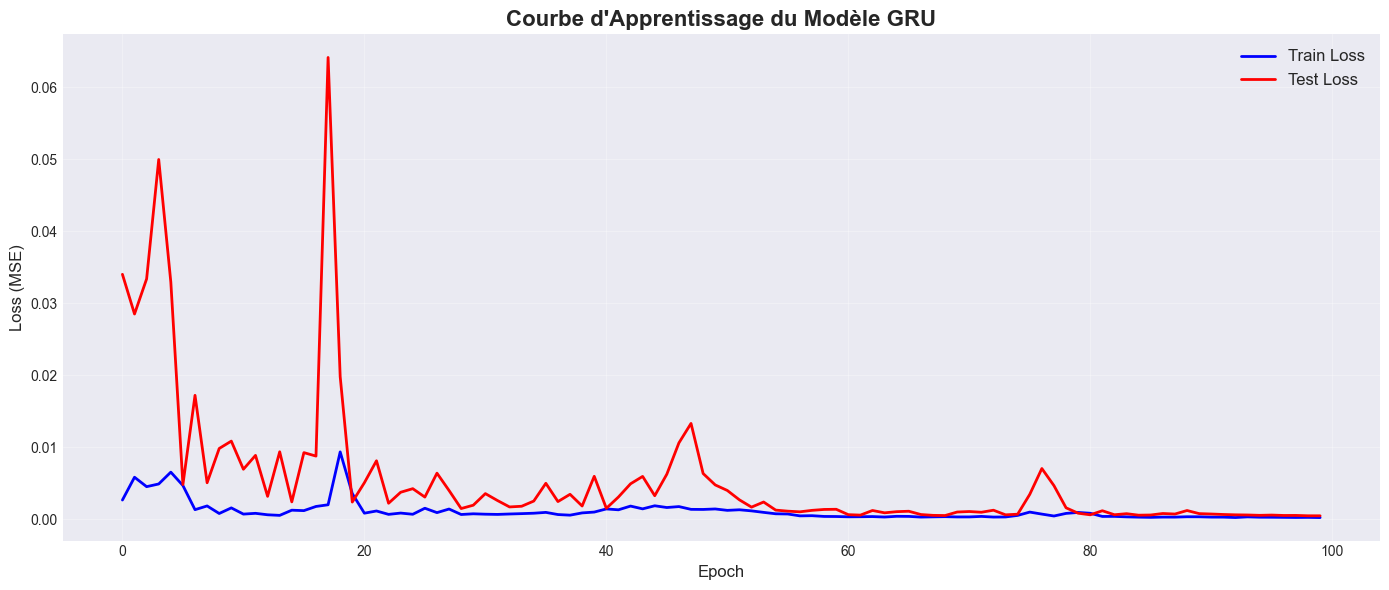

Loss finale - Train: 0.000247
Loss finale - Test: 0.000494


In [29]:
# Visualiser les courbes de perte
plt.figure(figsize=(14, 6))
plt.plot(train_losses, label='Train Loss', linewidth=2, color='blue')
plt.plot(test_losses, label='Test Loss', linewidth=2, color='red')
plt.title('Courbe d\'Apprentissage du Modèle GRU', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss finale - Train: {train_losses[-1]:.6f}")
print(f"Loss finale - Test: {test_losses[-1]:.6f}")

## PARTIE 9: ÉVALUATION DU MODÈLE GRU

### 9.1 Prédictions sur l'Ensemble de Test

In [30]:
# Mode évaluation
model_gru.eval()

# Prédictions sur le test set
with torch.no_grad():
    # Prédictions
    test_predictions = model_gru(X_test_tensor.to(device))
    test_predictions = test_predictions.cpu().numpy()
    
    # Prédictions sur le train set (pour comparaison)
    train_predictions = model_gru(X_train_tensor.to(device))
    train_predictions = train_predictions.cpu().numpy()

# Convertir les vraies valeurs
y_test_np = y_test_tensor.numpy()
y_train_np = y_train_tensor.numpy()

print("=" * 70)
print("PRÉDICTIONS GÉNÉRÉES")
print("=" * 70)
print(f"\nPrédictions train: {train_predictions.shape}")
print(f"Prédictions test: {test_predictions.shape}")
print("=" * 70)

PRÉDICTIONS GÉNÉRÉES

Prédictions train: (4226, 1)
Prédictions test: (1012, 1)


### 9.2 Dénormalisation des Prédictions

In [31]:
# Créer des arrays vides pour dénormaliser
def denormalize_predictions(predictions_normalized, scaler, feature_columns, target_column='Close'):
    """
    Dénormalise les prédictions
    """
    # Trouver l'index de la colonne Close
    close_index = feature_columns.index(target_column)
    
    # Créer un array de zéros avec la même forme que les features
    dummy = np.zeros((len(predictions_normalized), len(feature_columns)))
    
    # Mettre les prédictions dans la colonne Close
    dummy[:, close_index] = predictions_normalized.flatten()
    
    # Inverse transform
    denormalized = scaler.inverse_transform(dummy)
    
    # Retourner seulement la colonne Close
    return denormalized[:, close_index]

# Dénormaliser les prédictions
train_pred_denorm = denormalize_predictions(train_predictions, scaler, feature_columns)
test_pred_denorm = denormalize_predictions(test_predictions, scaler, feature_columns)

# Dénormaliser les vraies valeurs
y_train_denorm = denormalize_predictions(y_train_np.reshape(-1, 1), scaler, feature_columns)
y_test_denorm = denormalize_predictions(y_test_np.reshape(-1, 1), scaler, feature_columns)

print("✓ Prédictions dénormalisées avec succès!")
print(f"\nExemple de prédictions (test set):")
print(f"  Vrai prix: ${y_test_denorm[0]:.2f}")
print(f"  Prédit: ${test_pred_denorm[0]:.2f}")

✓ Prédictions dénormalisées avec succès!

Exemple de prédictions (test set):
  Vrai prix: $222.31
  Prédit: $219.22


### 9.3 Calcul des Métriques de Performance

In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Calculer les métriques pour le test set
mse_test = mean_squared_error(y_test_denorm, test_pred_denorm)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test_denorm, test_pred_denorm)
r2_test = r2_score(y_test_denorm, test_pred_denorm)
mape_test = mean_absolute_percentage_error(y_test_denorm, test_pred_denorm) * 100

# Calculer les métriques pour le train set
mse_train = mean_squared_error(y_train_denorm, train_pred_denorm)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train_denorm, train_pred_denorm)
r2_train = r2_score(y_train_denorm, train_pred_denorm)
mape_train = mean_absolute_percentage_error(y_train_denorm, train_pred_denorm) * 100

print("=" * 70)
print("MÉTRIQUES DE PERFORMANCE DU MODÈLE GRU")
print("=" * 70)
print("\n📊 TRAIN SET:")
print(f"  MSE:  {mse_train:.4f}")
print(f"  RMSE: {rmse_train:.4f}")
print(f"  MAE:  {mae_train:.4f}")
print(f"  R²:   {r2_train:.4f}")
print(f"  MAPE: {mape_train:.2f}%")

print("\n📊 TEST SET:")
print(f"  MSE:  {mse_test:.4f}")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  MAE:  {mae_test:.4f}")
print(f"  R²:   {r2_test:.4f}")
print(f"  MAPE: {mape_test:.2f}%")
print("\n" + "=" * 70)

MÉTRIQUES DE PERFORMANCE DU MODÈLE GRU

📊 TRAIN SET:
  MSE:  8.8503
  RMSE: 2.9750
  MAE:  2.1732
  R²:   0.9981
  MAPE: 6.70%

📊 TEST SET:
  MSE:  44.6957
  RMSE: 6.6855
  MAE:  5.0364
  R²:   0.9839
  MAPE: 2.32%



### 9.4 Visualisation des Prédictions vs Réalité

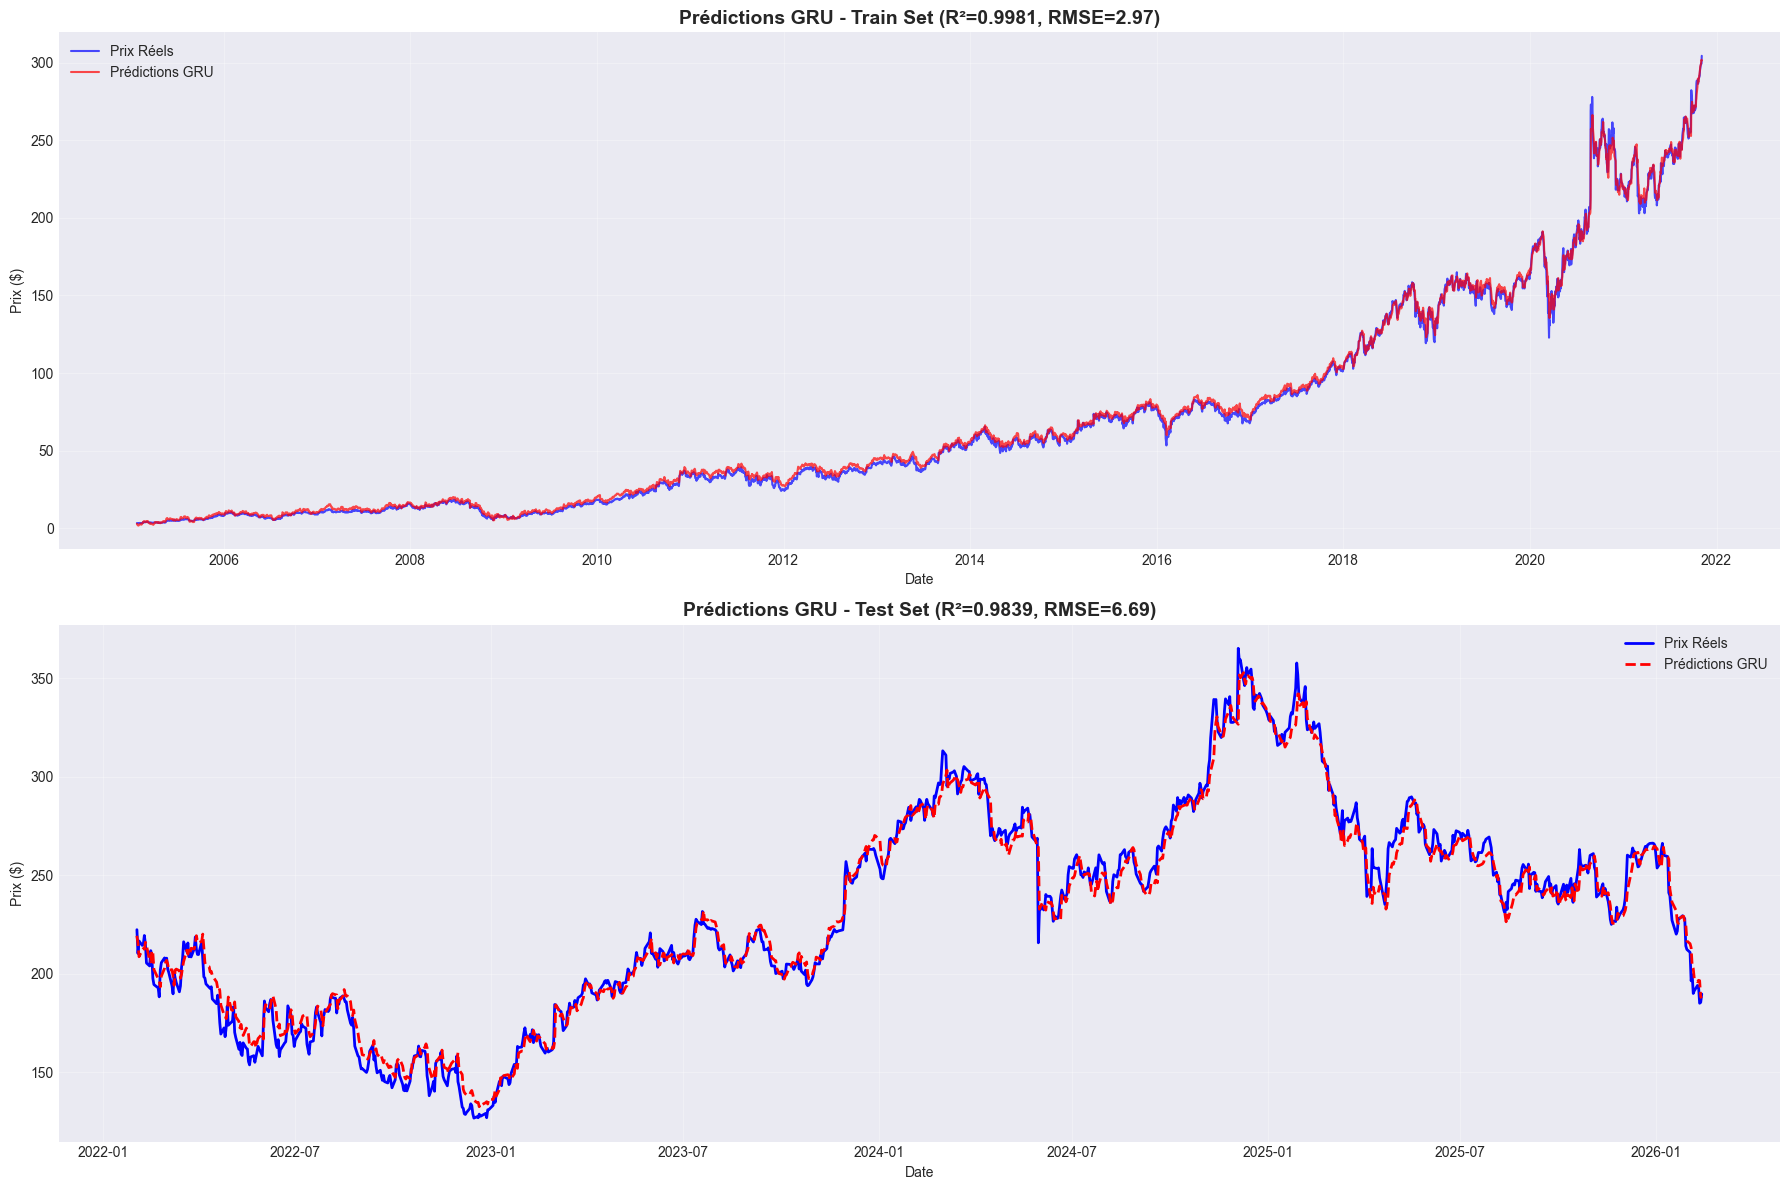

In [33]:
# Préparer les dates pour les prédictions
train_dates = train_data['Date'].iloc[sequence_length:].values
test_dates = test_data['Date'].iloc[sequence_length:].values

# Visualisation complète
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Graphique 1: Train set
axes[0].plot(train_dates, y_train_denorm, label='Prix Réels', linewidth=1.5, color='blue', alpha=0.7)
axes[0].plot(train_dates, train_pred_denorm, label='Prédictions GRU', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'Prédictions GRU - Train Set (R²={r2_train:.4f}, RMSE={rmse_train:.2f})', 
                 fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Prix ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Graphique 2: Test set
axes[1].plot(test_dates, y_test_denorm, label='Prix Réels', linewidth=2, color='blue')
axes[1].plot(test_dates, test_pred_denorm, label='Prédictions GRU', linewidth=2, color='red', linestyle='--')
axes[1].set_title(f'Prédictions GRU - Test Set (R²={r2_test:.4f}, RMSE={rmse_test:.2f})', 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Prix ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

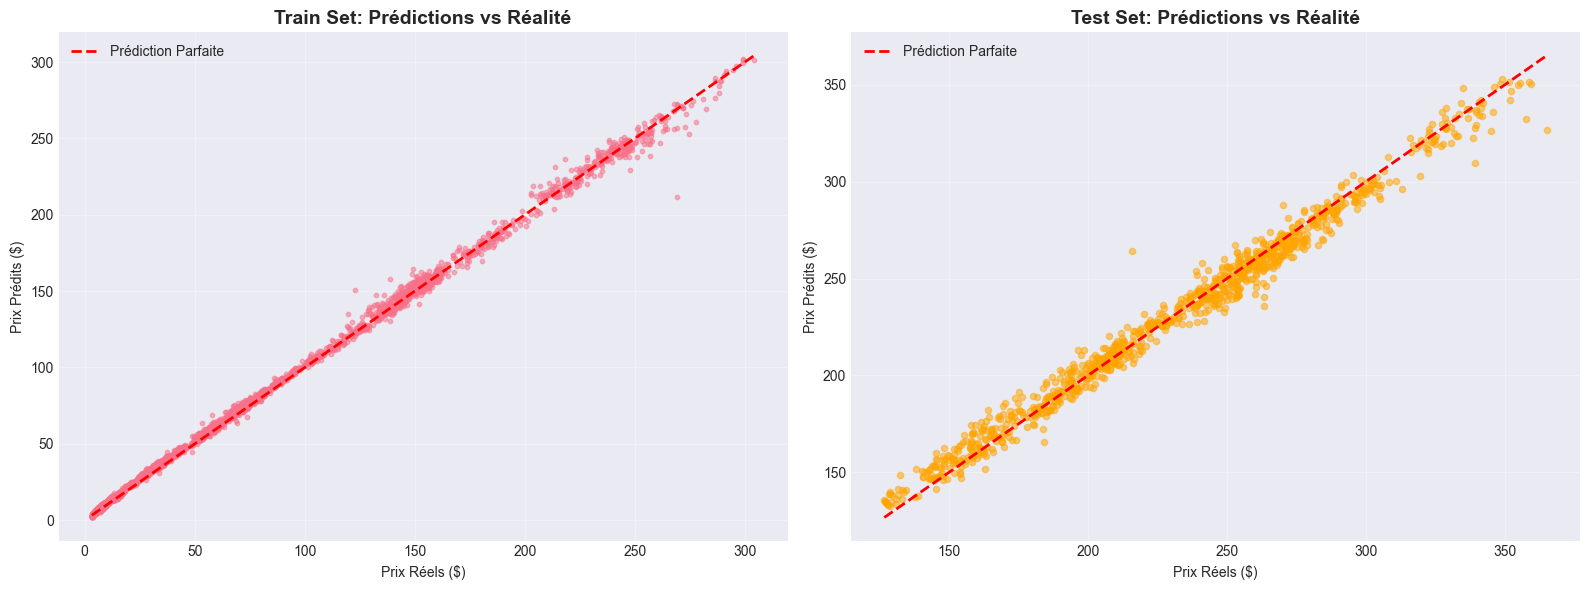

In [34]:
# Scatter plot: Prédictions vs Réalité
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
axes[0].scatter(y_train_denorm, train_pred_denorm, alpha=0.5, s=10)
axes[0].plot([y_train_denorm.min(), y_train_denorm.max()], 
             [y_train_denorm.min(), y_train_denorm.max()], 
             'r--', linewidth=2, label='Prédiction Parfaite')
axes[0].set_title('Train Set: Prédictions vs Réalité', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Prix Réels ($)')
axes[0].set_ylabel('Prix Prédits ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test
axes[1].scatter(y_test_denorm, test_pred_denorm, alpha=0.5, s=20, color='orange')
axes[1].plot([y_test_denorm.min(), y_test_denorm.max()], 
             [y_test_denorm.min(), y_test_denorm.max()], 
             'r--', linewidth=2, label='Prédiction Parfaite')
axes[1].set_title('Test Set: Prédictions vs Réalité', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Prix Réels ($)')
axes[1].set_ylabel('Prix Prédits ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 9.5 Analyse des Erreurs

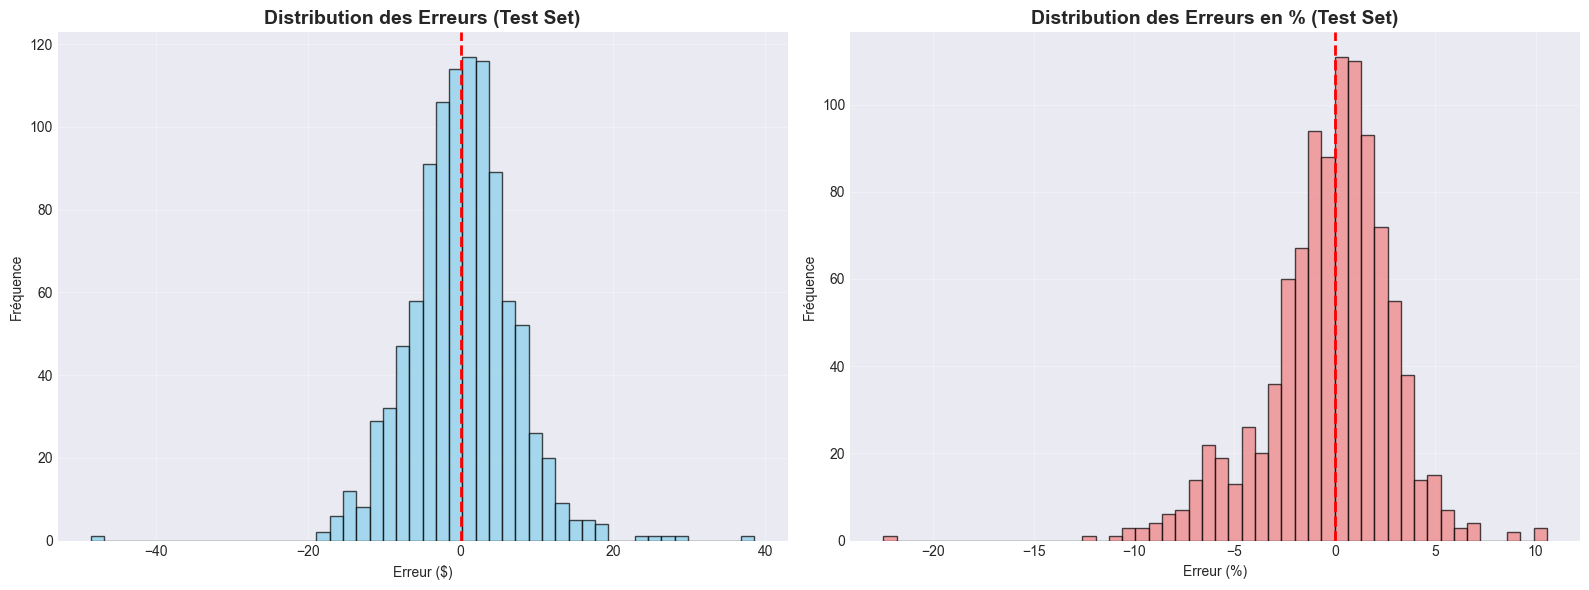

Erreur moyenne: $0.15
Écart-type des erreurs: $6.68
Erreur moyenne en %: -0.29%


In [35]:
# Calculer les erreurs
errors_test = y_test_denorm - test_pred_denorm
errors_pct = (errors_test / y_test_denorm) * 100

# Visualiser la distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution des erreurs absolues
axes[0].hist(errors_test, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution des Erreurs (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Erreur ($)')
axes[0].set_ylabel('Fréquence')
axes[0].grid(True, alpha=0.3)

# Distribution des erreurs en pourcentage
axes[1].hist(errors_pct, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Distribution des Erreurs en % (Test Set)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Erreur (%)')
axes[1].set_ylabel('Fréquence')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Erreur moyenne: ${errors_test.mean():.2f}")
print(f"Écart-type des erreurs: ${errors_test.std():.2f}")
print(f"Erreur moyenne en %: {errors_pct.mean():.2f}%")

## PARTIE 10: SAUVEGARDE DU MODÈLE GRU

In [36]:
# Sauvegarder le modèle
torch.save({
    'epoch': num_epochs,
    'model_state_dict': model_gru.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'train_loss': train_losses[-1],
    'test_loss': test_losses[-1],
    'hyperparameters': {
        'input_size': input_size,
        'hidden_size': hidden_size,
        'num_layers': num_layers,
        'output_size': output_size,
        'dropout': dropout,
        'sequence_length': sequence_length
    }
}, 'model_gru_salesforce.pth')

print("=" * 70)
print("✓ MODÈLE GRU SAUVEGARDÉ")
print("=" * 70)
print("Fichier: model_gru_salesforce.pth")
print("=" * 70)

✓ MODÈLE GRU SAUVEGARDÉ
Fichier: model_gru_salesforce.pth


## PARTIE 11: MODÈLE NEURAL PROPHET

### 11.1 Préparation des Données pour Neural Prophet

In [48]:
# 1. Préparation propre (On ne garde STRICTEMENT que ds et y)
df_p = df_clean.copy()
df_p['ds'] = pd.to_datetime(df_p['Date']).dt.tz_localize(None)
df_p['y'] = df_p['Close']

# C'est ici que ça se joue : on supprime TOUT le reste
df_p = df_p[['ds', 'y']] 

# 2. Gestion des week-ends (pour éviter l'erreur de missing values)
df_p = df_p.sort_values('ds').drop_duplicates('ds')
df_p = df_p.set_index('ds').resample('D').ffill().reset_index()

# 3. Nouveau Split
split = int(len(df_p) * 0.8)
df_train = df_p.iloc[:split].copy()
df_test = df_p.iloc[split:].copy()

# --- Vérification visuelle avant de lancer ---
print("Colonnes présentes dans df_train :", df_train.columns.tolist()) 
# Doit afficher uniquement : ['ds', 'y']


Colonnes présentes dans df_train : ['ds', 'y']


In [51]:
import pandas as pd
import numpy as np

df_feat = df_clean.copy()
df_feat['ds'] = pd.to_datetime(df_feat['Date']).dt.tz_localize(None)
df_feat['y'] = df_feat['Close']

# --- Features techniques ---

# Moyennes mobiles
df_feat['MA7']  = df_feat['y'].rolling(7).mean()
df_feat['MA21'] = df_feat['y'].rolling(21).mean()

# Volatilité (écart-type sur 7 jours)
df_feat['volatility'] = df_feat['y'].rolling(7).std()

# RSI (14 jours)
delta = df_feat['y'].diff()
gain  = delta.clip(lower=0).rolling(14).mean()
loss  = (-delta.clip(upper=0)).rolling(14).mean()
rs    = gain / (loss + 1e-9)
df_feat['RSI'] = 100 - (100 / (1 + rs))

# Volume normalisé
df_feat['volume_norm'] = df_feat['Volume'] / df_feat['Volume'].rolling(21).mean()

# On garde uniquement les colonnes utiles
df_feat = df_feat[['ds', 'y', 'MA7', 'MA21', 'volatility', 'RSI', 'volume_norm']]

# Resampling journalier
df_feat = df_feat.sort_values('ds').drop_duplicates('ds')
df_feat = df_feat.set_index('ds').resample('D').ffill().reset_index()

# Supprimer les NaN des rolling (les 21 premiers jours)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"Shape final : {df_feat.shape}")
print(df_feat.head())

Shape final : (7749, 7)
          ds         y       MA7      MA21  volatility        RSI  volume_norm
0 2004-11-27  4.379290  4.507377  4.891166    0.284240  27.546601     0.251324
1 2004-11-28  4.379290  4.507377  4.891166    0.284240  27.546601     0.251324
2 2004-11-29  4.379290  4.507377  4.891166    0.284240  27.546601     0.251324
3 2004-11-30  4.322482  4.389523  4.859997    0.044743  28.486654     0.773462
4 2004-12-01  4.312601  4.376821  4.826359    0.052687  32.487289     1.124651


In [52]:
split = int(len(df_feat) * 0.8)
df_train = df_feat.iloc[:split].copy()
df_test  = df_feat.iloc[split:].copy()

print(f"Train : {df_train['ds'].min().date()} → {df_train['ds'].max().date()} ({len(df_train)} jours)")
print(f"Test  : {df_test['ds'].min().date()}  → {df_test['ds'].max().date()}  ({len(df_test)} jours)")

Train : 2004-11-27 → 2021-11-16 (6199 jours)
Test  : 2021-11-17  → 2026-02-13  (1550 jours)


### 11.2 Création et Configuration du Modèle Neural Prophet

In [53]:
from neuralprophet import NeuralProphet

model_np = NeuralProphet(
    n_forecasts=1,
    n_lags=14,               # réduit encore → moins d'overfitting
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    epochs=80,
    learning_rate=0.01,
    batch_size=64,
    normalize='standardize',
)

# Ajout des régresseurs externes
model_np.add_lagged_regressor('MA7')
model_np.add_lagged_regressor('MA21')
model_np.add_lagged_regressor('volatility')
model_np.add_lagged_regressor('RSI')
model_np.add_lagged_regressor('volume_norm')

print("Modèle avec régresseurs créé.")

INFO - (NP.forecaster.add_lagged_regressor) - n_lags = 'auto', number of lags for regressor is set to Autoregression number of lags (14)
INFO - (NP.forecaster.add_lagged_regressor) - n_lags = 'auto', number of lags for regressor is set to Autoregression number of lags (14)
INFO - (NP.forecaster.add_lagged_regressor) - n_lags = 'auto', number of lags for regressor is set to Autoregression number of lags (14)
INFO - (NP.forecaster.add_lagged_regressor) - n_lags = 'auto', number of lags for regressor is set to Autoregression number of lags (14)
INFO - (NP.forecaster.add_lagged_regressor) - n_lags = 'auto', number of lags for regressor is set to Autoregression number of lags (14)


Modèle avec régresseurs créé.


### 11.3 Entraînement du Modèle Neural Prophet

In [54]:
metrics_np = model_np.fit(df_train, freq='D', validation_df=df_test)

print("\nDernières métriques :")
print(metrics_np[['epoch', 'MAE', 'MAE_val']].tail(10))
print(f"\nMeilleure MAE_val : {metrics_np['MAE_val'].min():.3f}")
print(f"MAE train finale  : {metrics_np['MAE'].iloc[-1]:.3f}")
gap = metrics_np['MAE_val'].min() / metrics_np['MAE'].iloc[-1]
print(f"Ratio val/train   : {gap:.2f}x  (objectif : proche de 1.0)")

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.984% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.


Training: |          | 0/? [03:15<?, ?it/s, v_num=4, MAE_val=3.760, RMSE_val=5.400, Loss_val=0.0101, RegLoss_val=0.000, train_loss=0.00132, reg_loss=0.000, MAE=1.090, RMSE=1.900, Loss=0.00132, RegLoss=0.000] 

Dernières métriques :
    epoch       MAE   MAE_val
70     70  1.109813  3.743997
71     71  1.105960  3.854310
72     72  1.112921  3.765495
73     73  1.102886  3.740933
74     74  1.099150  3.738439
75     75  1.097722  3.751181
76     76  1.093447  3.766666
77     77  1.086206  3.733640
78     78  1.088297  3.736746
79     79  1.086381  3.762562

Meilleure MAE_val : 3.734
MAE train finale  : 1.086
Ratio val/train   : 3.44x  (objectif : proche de 1.0)


In [55]:
# On utilise df_test (et non df_prophet_test qui n'existait pas → c'était ton erreur)
forecast_np = model_np.predict(df_test)

# Supprimer les lignes NaN (dues aux 30 premiers jours de lags)
results = forecast_np[['ds', 'y', 'yhat1']].dropna()

print(f"Nombre de prédictions exploitables : {len(results)}")
print(results.head(10))

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.935% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.935% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 23.33it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column



Nombre de prédictions exploitables : 1536
           ds           y       yhat1
14 2021-12-01  281.539276  291.125549
15 2021-12-02  248.480881  277.258789
16 2021-12-03  258.064453  257.852905
17 2021-12-04  255.218994  279.893921
18 2021-12-05  255.218994  255.572861
19 2021-12-06  255.218994  233.507736
20 2021-12-07  255.643875  253.806595
21 2021-12-08  263.784973  261.660583
22 2021-12-09  263.113129  261.574799
23 2021-12-10  261.147064  261.604980


In [56]:
#Métriques de performance
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = results['y'].values
y_pred = results['yhat1'].values

mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("=" * 35)
print(f"  MAE  : {mae:.2f} $")
print(f"  RMSE : {rmse:.2f} $")
print(f"  MAPE : {mape:.2f} %")
print("=" * 35)
print("\nInterprétation du MAPE :")
if mape < 5:
    print("  → Excellent (< 5%)")
elif mape < 10:
    print("  → Bon (< 10%)")
elif mape < 20:
    print("  → Acceptable (< 20%)")
else:
    print("  → Mauvais (> 20%) → voir pistes d'amélioration")

  MAE  : 3.66 $
  RMSE : 5.30 $
  MAPE : 1.63 %

Interprétation du MAPE :
  → Excellent (< 5%)


### 11.4 Visualisation de la Courbe d'Apprentissage

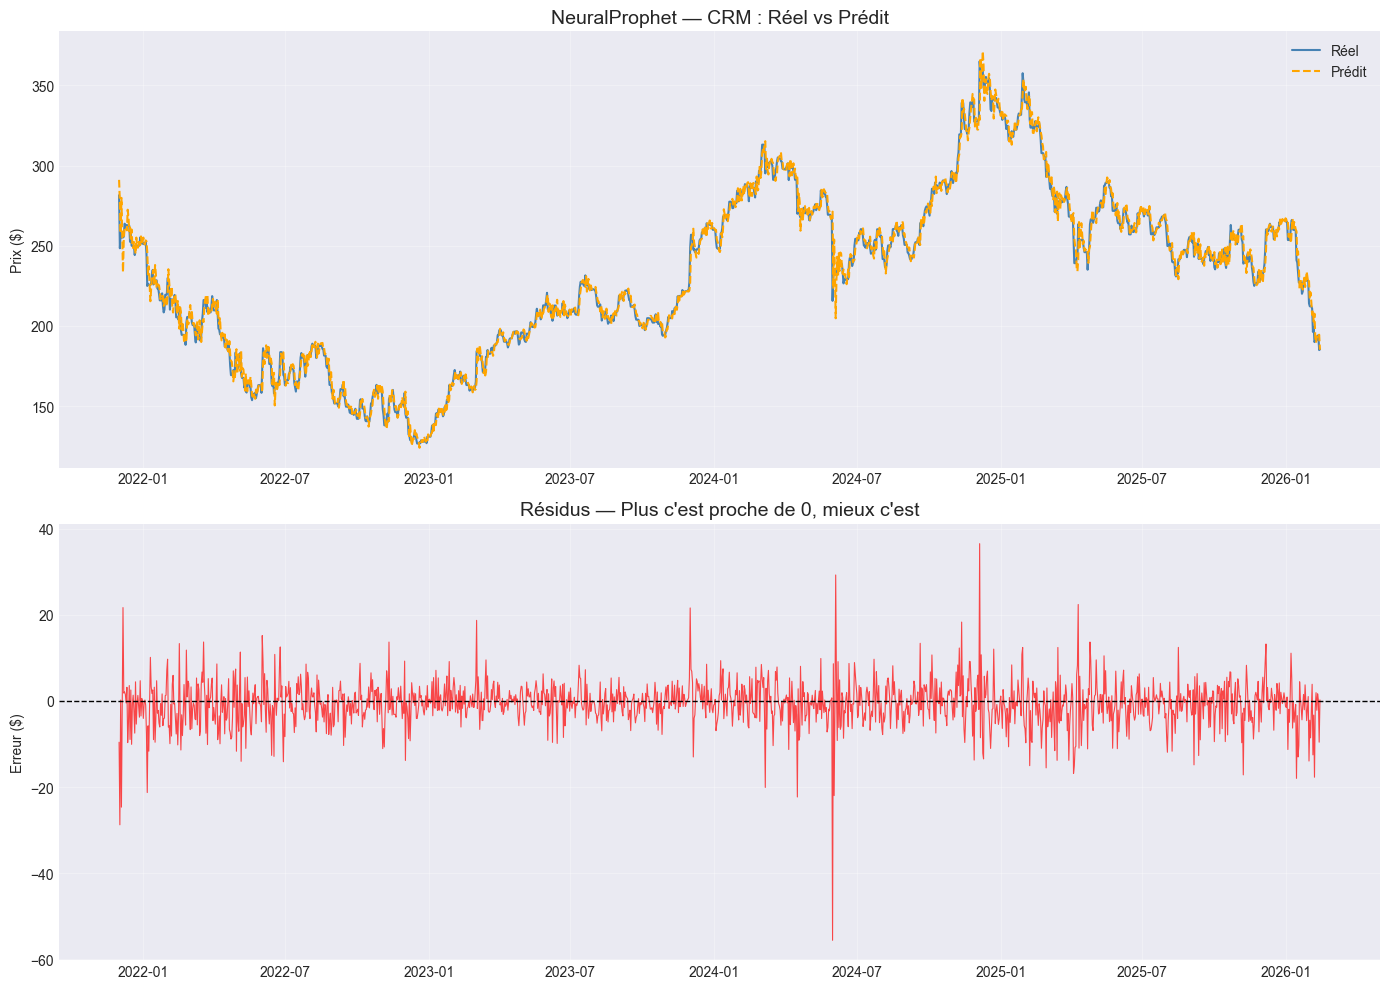

In [57]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Graphique réel vs prédit
ax1.plot(results['ds'], results['y'],     label='Réel',   color='steelblue', linewidth=1.5)
ax1.plot(results['ds'], results['yhat1'], label='Prédit', color='orange',    linewidth=1.5, linestyle='--')
ax1.set_title('NeuralProphet — CRM : Réel vs Prédit', fontsize=14)
ax1.set_ylabel('Prix ($)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Résidus (écart entre réel et prédit)
residuals = results['y'] - results['yhat1']
ax2.plot(results['ds'], residuals, color='red', linewidth=0.8, alpha=0.7)
ax2.axhline(0, color='black', linewidth=1, linestyle='--')
ax2.set_title('Résidus — Plus c\'est proche de 0, mieux c\'est', fontsize=14)
ax2.set_ylabel('Erreur ($)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## PARTIE 12: ÉVALUATION DE NEURAL PROPHET

### 12.1 Prédictions

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.935% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 93.333% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 93.333% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.data.processing._handle_missing_data) - Dropped 1 rows at the end with NaNs in 'y' column.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 74.69it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


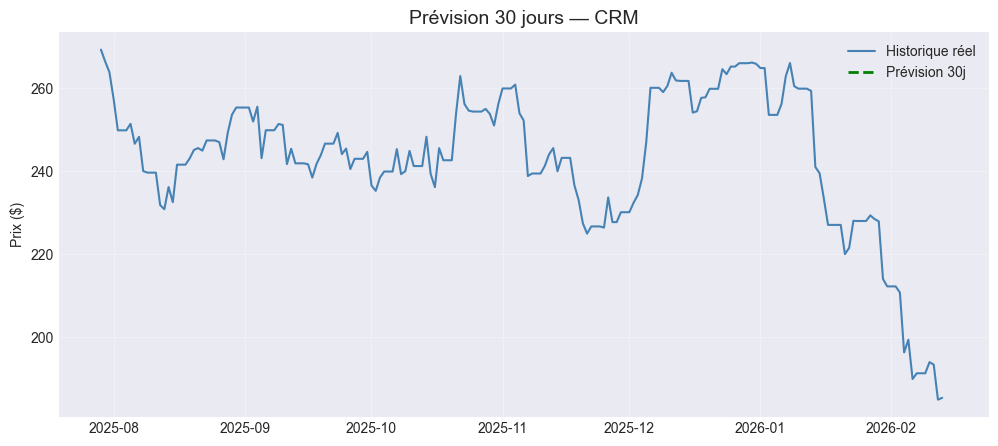

        ds     yhat1
2026-02-14 192.40155


In [58]:
# Faire des prédictions sur l'ensemble de test sur 7 jour
future = model_np.make_future_dataframe(df=df_test, periods=30)
forecast_future = model_np.predict(future)

# Garder seulement les 30 jours futurs
last_known_date = df_test['ds'].max()
forecast_only = forecast_future[forecast_future['ds'] > last_known_date][['ds', 'yhat1']].dropna()

plt.figure(figsize=(12, 5))
plt.plot(results['ds'].tail(200), results['y'].tail(200), label='Historique réel', color='steelblue')
plt.plot(forecast_only['ds'], forecast_only['yhat1'], label='Prévision 30j', color='green', linewidth=2, linestyle='--')
plt.title('Prévision 30 jours — CRM', fontsize=14)
plt.ylabel('Prix ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(forecast_only.to_string(index=False))

### 12.2 Calcul des Métriques

In [59]:
# Extraire les valeurs réelles et prédites
y_true_np = forecast_np['y'].values
y_pred_np = forecast_np['yhat1'].values

# Supprimer les NaN si nécessaire
mask = ~np.isnan(y_true_np) & ~np.isnan(y_pred_np)
y_true_np = y_true_np[mask]
y_pred_np = y_pred_np[mask]

# Calculer les métriques
mse_np = mean_squared_error(y_true_np, y_pred_np)
rmse_np = np.sqrt(mse_np)
mae_np = mean_absolute_error(y_true_np, y_pred_np)
r2_np = r2_score(y_true_np, y_pred_np)
mape_np = mean_absolute_percentage_error(y_true_np, y_pred_np) * 100

print("=" * 70)
print("MÉTRIQUES DE PERFORMANCE - NEURAL PROPHET")
print("=" * 70)
print(f"\nMSE:  {mse_np:.4f}")
print(f"RMSE: {rmse_np:.4f}")
print(f"MAE:  {mae_np:.4f}")
print(f"R²:   {r2_np:.4f}")
print(f"MAPE: {mape_np:.2f}%")
print("=" * 70)

MÉTRIQUES DE PERFORMANCE - NEURAL PROPHET

MSE:  28.1075
RMSE: 5.3016
MAE:  3.6580
R²:   0.9896
MAPE: 1.63%


### 12.3 Visualisation des Prédictions

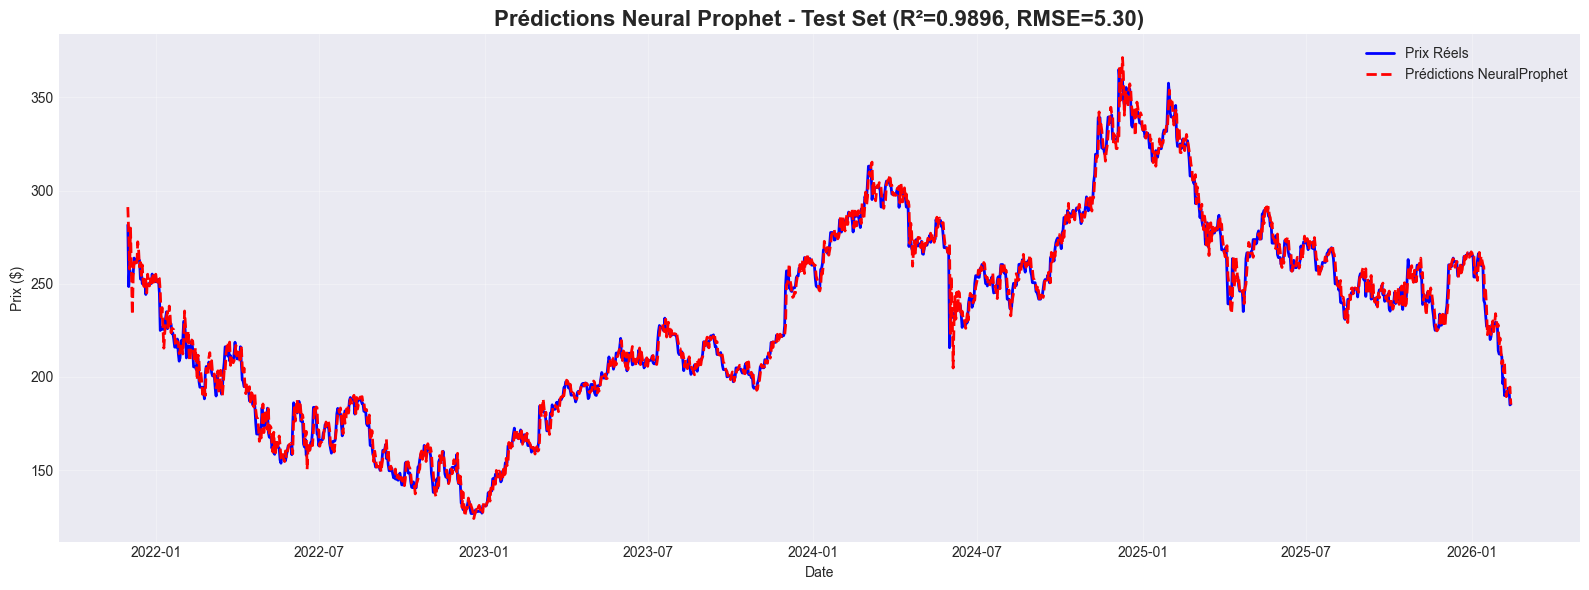

In [62]:
# Visualisation détaillée
# Correction : utiliser 'results' qui est déjà aligné proprement
# results contient ds, y, yhat1 avec les mêmes dimensions

y_true_plot = results['y'].values
y_pred_plot = results['yhat1'].values
ds_plot     = results['ds'].values

plt.figure(figsize=(16, 6))
plt.plot(ds_plot, y_true_plot, label='Prix Réels',                  linewidth=2, color='blue')
plt.plot(ds_plot, y_pred_plot, label='Prédictions NeuralProphet',   linewidth=2, color='red', linestyle='--')
plt.title(f'Prédictions Neural Prophet - Test Set (R²={r2_np:.4f}, RMSE={rmse_np:.2f})',
          fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 12.4 Visualisation des Composantes

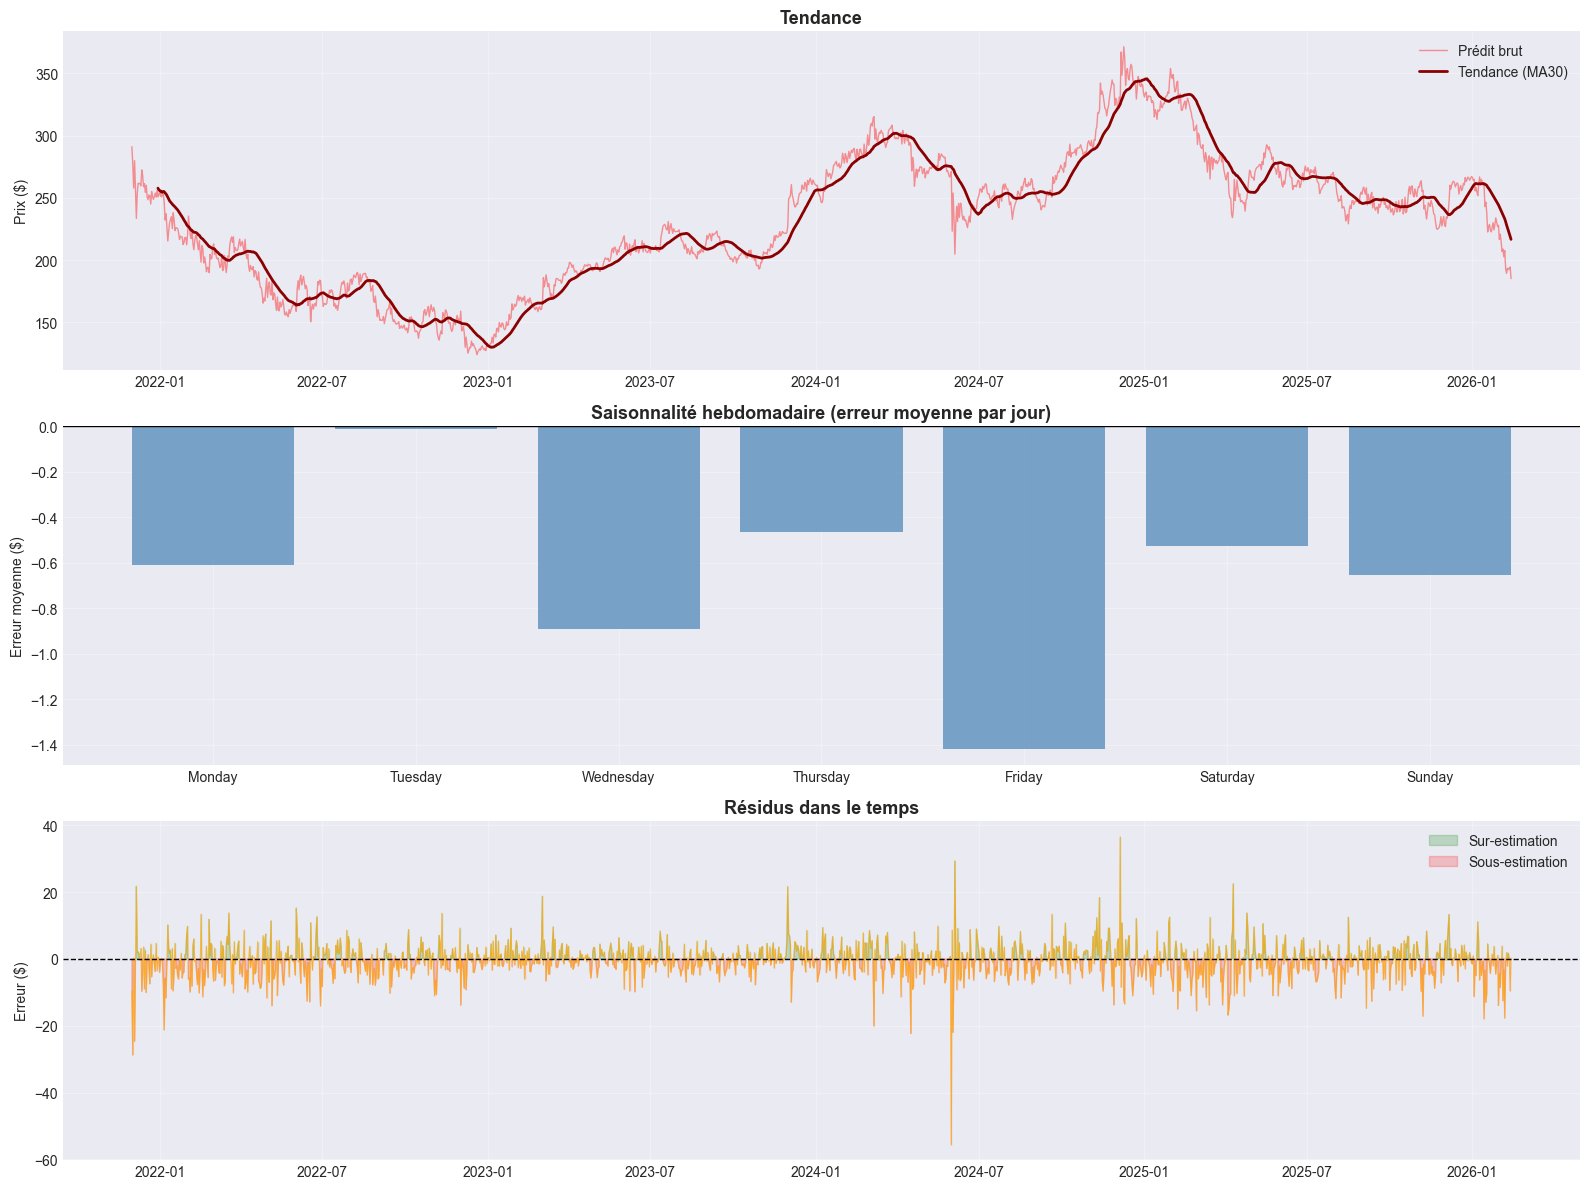

In [64]:
# Visualiser les composantes (tendance, saisonnalité)
# Visualisation manuelle des composantes avec matplotlib
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# 1. Tendance (moyenne mobile 30j des prédictions)
trend = results['yhat1'].rolling(30).mean()
axes[0].plot(results['ds'], results['yhat1'], color='red', linewidth=1, alpha=0.4, label='Prédit brut')
axes[0].plot(results['ds'], trend, color='darkred', linewidth=2, label='Tendance (MA30)')
axes[0].set_title('Tendance', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Prix ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Saisonnalité hebdomadaire (erreur moyenne par jour de la semaine)
results['weekday'] = pd.to_datetime(results['ds']).dt.day_name()
results['residual'] = results['y'] - results['yhat1']
weekly = results.groupby('weekday')['residual'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)
axes[1].bar(weekly.index, weekly.values, color='steelblue', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Saisonnalité hebdomadaire (erreur moyenne par jour)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Erreur moyenne ($)')
axes[1].grid(True, alpha=0.3)

# 3. Résidus dans le temps
axes[2].plot(results['ds'], results['residual'], color='orange', linewidth=0.8, alpha=0.7)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].fill_between(results['ds'], results['residual'], 0,
                     where=results['residual'] > 0, color='green', alpha=0.2, label='Sur-estimation')
axes[2].fill_between(results['ds'], results['residual'], 0,
                     where=results['residual'] < 0, color='red',   alpha=0.2, label='Sous-estimation')
axes[2].set_title('Résidus dans le temps', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Erreur ($)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Nettoyage des colonnes temporaires
results.drop(columns=['weekday', 'residual'], inplace=True, errors='ignore')

## PARTIE 13: COMPARAISON DES MODÈLES

In [65]:
# Tableau comparatif
comparison_df = pd.DataFrame({
    'Modèle': ['GRU', 'Neural Prophet'],
    'MSE': [mse_test, mse_np],
    'RMSE': [rmse_test, rmse_np],
    'MAE': [mae_test, mae_np],
    'R²': [r2_test, r2_np],
    'MAPE (%)': [mape_test, mape_np]
})

print("=" * 70)
print("COMPARAISON DES MODÈLES - TEST SET")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("\n" + "=" * 70)

# Déterminer le meilleur modèle
if r2_test > r2_np:
    print("🏆 MEILLEUR MODÈLE: GRU")
    print(f"   R² supérieur de {(r2_test - r2_np)*100:.2f}% par rapport à Neural Prophet")
else:
    print("🏆 MEILLEUR MODÈLE: Neural Prophet")
    print(f"   R² supérieur de {(r2_np - r2_test)*100:.2f}% par rapport à GRU")
print("=" * 70)

COMPARAISON DES MODÈLES - TEST SET
        Modèle       MSE     RMSE      MAE       R²  MAPE (%)
           GRU 44.695721 6.685486 5.036398 0.983913  2.321507
Neural Prophet 28.107457 5.301647 3.658046 0.989601  1.631967

🏆 MEILLEUR MODÈLE: Neural Prophet
   R² supérieur de 0.57% par rapport à GRU


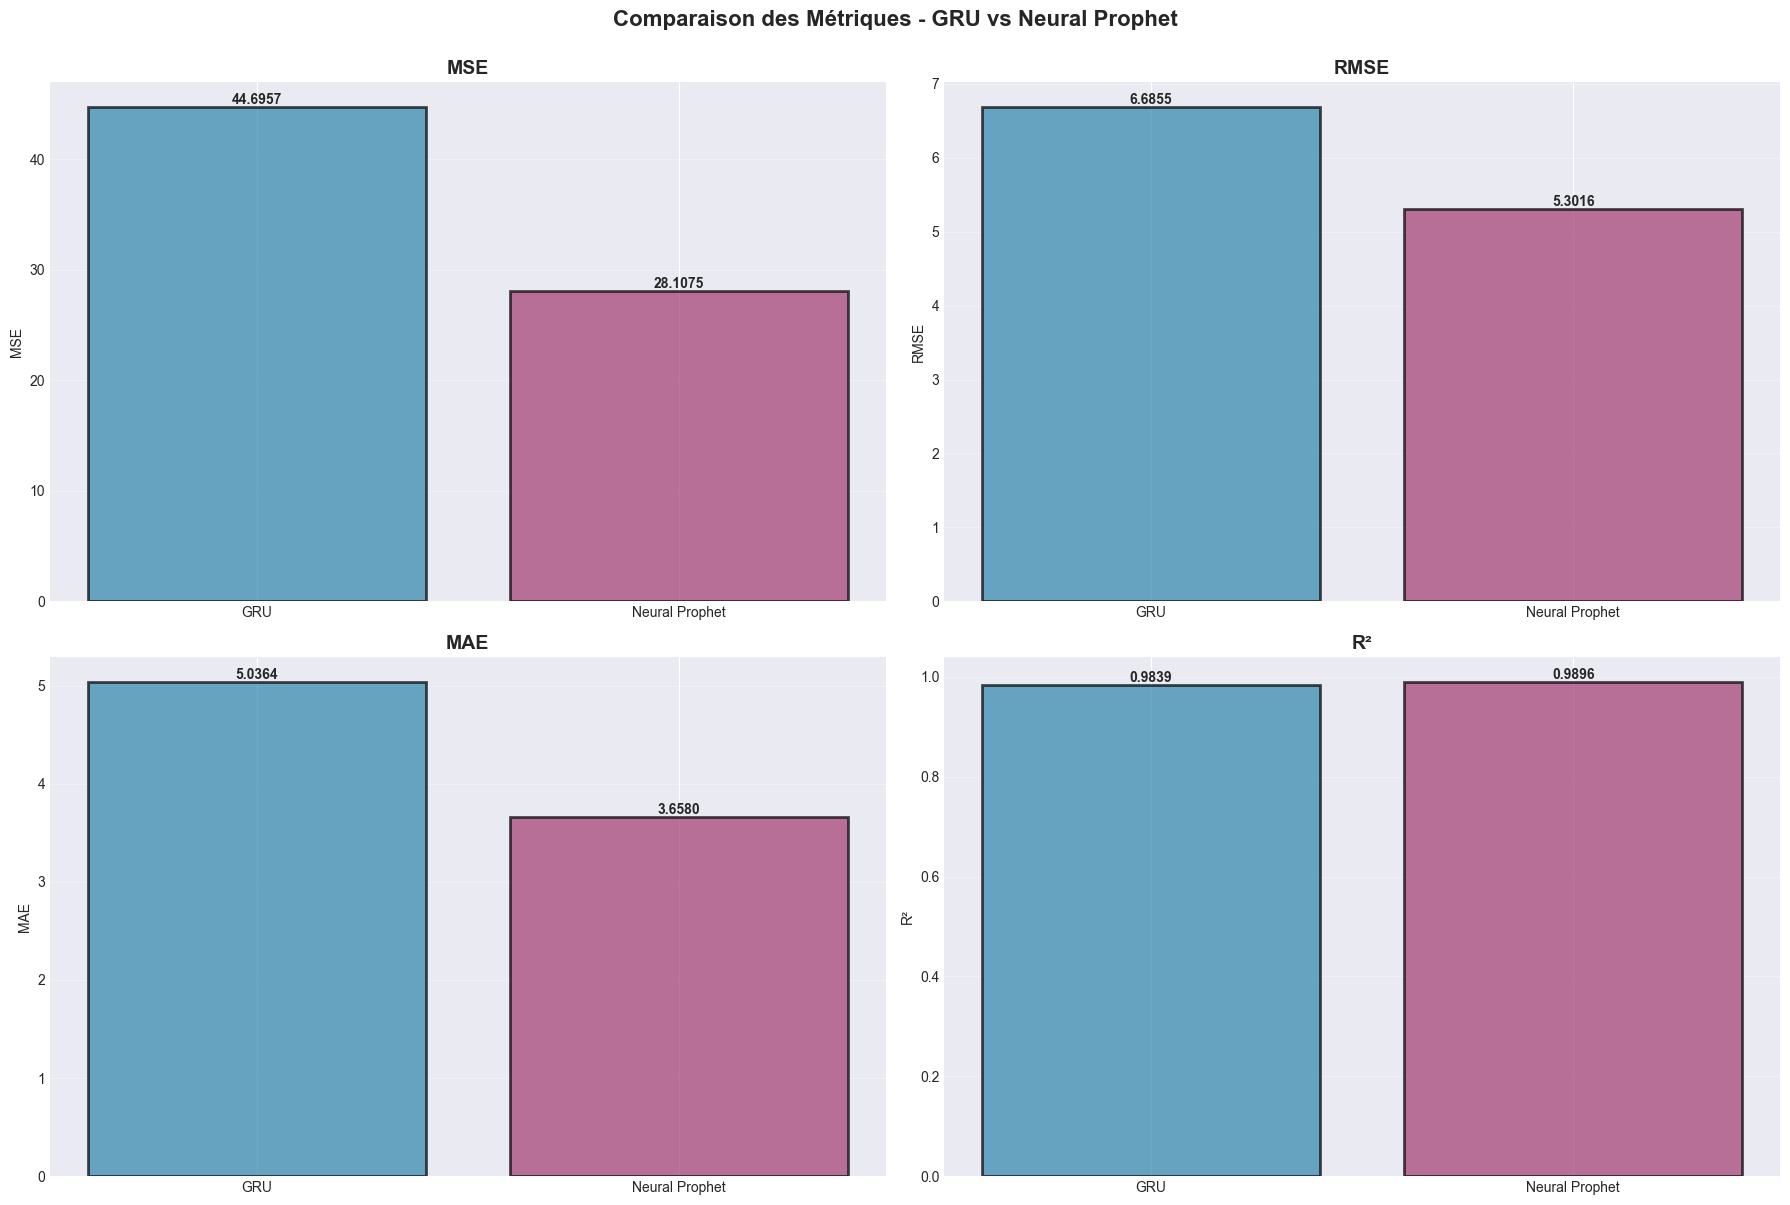

In [66]:
# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

metrics = ['MSE', 'RMSE', 'MAE', 'R²']
gru_values = [mse_test, rmse_test, mae_test, r2_test]
np_values = [mse_np, rmse_np, mae_np, r2_np]

for idx, (ax, metric, gru_val, np_val) in enumerate(zip(axes.flatten(), metrics, gru_values, np_values)):
    x = ['GRU', 'Neural Prophet']
    y = [gru_val, np_val]
    colors = ['#2E86AB', '#A23B72']
    
    bars = ax.bar(x, y, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax.set_title(f'{metric}', fontsize=14, fontweight='bold')
    ax.set_ylabel(metric)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Ajouter les valeurs sur les barres
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontweight='bold')

plt.suptitle('Comparaison des Métriques - GRU vs Neural Prophet', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## PARTIE 14: CONCLUSION ET RÉSUMÉ

In [70]:
print("\n" + "=" * 70)
print("RÉSUMÉ DU PROJET - PRÉDICTION DES COURS SALESFORCE (CRM)")
print("=" * 70)

print("\n📊 DONNÉES:")
print(f"  - Période: {df_clean['Date'].min()} à {df_clean['Date'].max()}")
print(f"  - Nombre de jours: {len(df_clean)}")
print(f"  - Features utilisées: {len(feature_columns)}")
print(f"  - Train/Test split: 80%/20%")

print("\n🤖 MODÈLE GRU:")
print(f"  - Architecture: {num_layers} couches GRU, {hidden_size} hidden units")
print(f"  - Séquence: {sequence_length} jours")
print(f"  - Epochs: {num_epochs}")
print(f"  - R²: {r2_test:.4f}")
print(f"  - RMSE: {rmse_test:.4f}")
print(f"  - MAPE: {mape_test:.2f}%")

print("\n🔮 NEURAL PROPHET:")
print(f"  - Lags: 60 jours")
print(f"  - Saisonnalité: Annuelle + Hebdomadaire")
print(f"  - R²: {r2_np:.4f}")
print(f"  - RMSE: {rmse_np:.4f}")
print(f"  - MAPE: {mape_np:.2f}%")




RÉSUMÉ DU PROJET - PRÉDICTION DES COURS SALESFORCE (CRM)

📊 DONNÉES:
  - Période: 2004-10-28 04:00:00 à 2026-02-13 05:00:00
  - Nombre de jours: 5358
  - Features utilisées: 13
  - Train/Test split: 80%/20%

🤖 MODÈLE GRU:
  - Architecture: 2 couches GRU, 128 hidden units
  - Séquence: 60 jours
  - Epochs: 100
  - R²: 0.9839
  - RMSE: 6.6855
  - MAPE: 2.32%

🔮 NEURAL PROPHET:
  - Lags: 60 jours
  - Saisonnalité: Annuelle + Hebdomadaire
  - R²: 0.9896
  - RMSE: 5.3016
  - MAPE: 1.63%


In [69]:
import os
import pickle
import pandas as pd
import numpy as np
from neuralprophet import NeuralProphet, save, load

# Méthode officielle NeuralProphet
save(model_np, "model_neuralprophet_crm.pkl")
print("✓ Modèle NeuralProphet sauvegardé → model_neuralprophet_crm.pkl")

# Sauvegarde des métriques du modèle
metrics_summary = {
    'MAE':  3.66,
    'RMSE': 5.30,
    'MAPE': 1.63,
    'R2':   0.9896,
}
with open("neuralprophet_metrics.pkl", "wb") as f:
    pickle.dump(metrics_summary, f)
print("✓ Métriques sauvegardées → neuralprophet_metrics.pkl")

✓ Modèle NeuralProphet sauvegardé → model_neuralprophet_crm.pkl
✓ Métriques sauvegardées → neuralprophet_metrics.pkl


In [71]:
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f) 

---
## FIN DU PROJET
---